# drop : false means full derivative
# drop : true, result no change, reduce cost

In [34]:
import time
import torch
import torch.nn as nn
import scipy
from scipy.io import loadmat
from scipy.spatial import cKDTree, distance
from scipy.spatial.distance import cdist
from scipy.linalg import solve, lstsq, lu_factor, lu_solve
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve, splu
import numpy as np
import math
from math import pi
import matplotlib.pyplot as plt


dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

def relative_loss(predict, exact):
    error = torch.sqrt(torch.sum((predict - exact) ** 2)) / torch.sqrt(torch.sum((exact) ** 2))
    return error

def vandercorput(n, base):
    """
    Vectorized van der Corput for n = array-like nonnegative integers and given base.
    Returns array of same shape as n with values in [0,1).
    """
    n = np.asarray(n, dtype=np.int64)
    # compute digits for each n by repeated division
    out = np.zeros_like(n, dtype=np.float64)
    denom = base
    current = n.copy()
    while np.any(current > 0):
        digit = current % base
        out += digit / denom
        current = current // base
        denom *= base
    return out

def halton_sequence(N, dim):
    """
    Generate first N points of Halton sequence in `dim` dimensions.
    Uses first `dim` primes as bases.
    Returns array shape (N, dim) with values in [0,1).
    """
    # small prime list sufficient for moderate dim
    primes_list = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59]
    if dim > len(primes_list):
        raise ValueError("Requested dimension too large for built-in primes list.")
    bases = primes_list[:dim]
    n_idx = np.arange(0, N, dtype=np.int64)  # n = 0..N-1
    H = np.empty((N, dim), dtype=np.float64)
    for j, b in enumerate(bases):
        H[:, j] = vandercorput(n_idx, b)
    return H

def generator_points_star(N_patch_grid,
                     N_local_per_patch,
                     N_boundary,
                     R_ptch,
                     mode="c-rbf-pum"):
    """
    Generate points on a star-shaped region and patch covering.

    Parameters
    ----------
    N_patch_grid : int
        number of patches per dimension (grid)
    N_local_per_patch : int
        target local points per patch (used as halton sample size per patch)
    N_boundary : int
        number of boundary points
    R_ptch : float
        patch radius
    mode : str
        "c-rbf-pum" or "ls-rbf-pum"

    Returns
    -------
    X_inner : ndarray (N_x,2)
        concatenated interior/source points
    X_boundary : ndarray (N_boundary,2)
        boundary points (uniform in theta)
    ptch : dict
        {'C': array(P,2), 'R': array(P,) } patch centers and radii
    grid_eval : ndarray (N_eval,2)
        evaluation/prediction points (depends on mode)
    """
    # -------------------------
    # 1. star region radial function
    def r_max_func(theta):
        return 2.0 * (0.7 + 0.12 * (np.sin(6*theta) + np.sin(3*theta)))

    # vector theta for plotting / sampling
    theta_plot = np.linspace(0.0, 2*np.pi, 1000, endpoint=False)
    r_plot = r_max_func(theta_plot)
    x_plot = r_plot * np.cos(theta_plot)
    y_plot = r_plot * np.sin(theta_plot)

    x_min, x_max = x_plot.min(), x_plot.max()
    y_min, y_max = y_plot.min(), y_plot.max()
    R_container = r_plot.max()

    # helper: is point(s) inside star region (vectorized)
    def is_inside_star(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        r = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        theta = np.where(theta < 0, theta + 2*np.pi, theta)
        r_limit = r_max_func(theta)
        TOL = 1e-12
        return r <= (r_limit + TOL)

    # -------------------------
    # 2. Patch grid parameters
    Domain_size = max(x_max - x_min, y_max - y_min)
    num_patches_1D = int(N_patch_grid)
    # avoid division by zero when Domain_size small
    if num_patches_1D <= 1:
        del_param = 0.0
    else:
        del_param = (num_patches_1D - Domain_size / R_ptch) / (num_patches_1D - 1)
    patch_spacing = 2 * R_ptch * (1 - del_param)

    # create center grid in bounding square [Grid_min, Grid_max]^2
    Grid_min = min(x_min, y_min)
    Grid_max = max(x_max, y_max)
    Cx = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cy = np.linspace(Grid_min, Grid_max, num_patches_1D)
    Cxv, Cyv = np.meshgrid(Cx, Cy)
    C_all = np.column_stack([Cxv.ravel(), Cyv.ravel()])
    R_all = R_ptch * np.ones((C_all.shape[0],), dtype=np.float64)

    # For each candidate patch, sample its circle boundary points and check overlap
    theta_circ = theta_plot  # reuse dense sample
    # build for all centers: shifted circle coordinates
    # shape (num_centers, n_theta)
    bc_x = C_all[:, 0:1] + R_all[:, None] * np.cos(theta_circ)[None, :]
    bc_y = C_all[:, 1:] + R_all[:, None] * np.sin(theta_circ)[None, :]

    # Determine which patch has any boundary point inside the star region
    # is_inside_star accepts arrays; compute over all boundary samples
    inside_flags = is_inside_star(bc_x, bc_y)  # shape (num_centers, n_theta)
    id_keep = np.where(inside_flags.sum(axis=1) > 0)[0]

    C_kept = C_all[id_keep, :]
    R_kept = R_all[id_keep]
    ptch = {'C': C_kept, 'R': R_kept}
    P = C_kept.shape[0]

    # -------------------------
    # 3. Generate RBF center points per patch (Halton sampling in polar coords)
    X_inner_points = []
    grid_eval_points = []  # for c-rbf-pum mode
    # we will use exactly N_local_per_patch halton samples per patch (as in your adjusted code)
    N_generate = int(N_local_per_patch)
    # for LS mode, generate global evaluation grid if requested
    if mode == "ls-rbf-pum":
        # create a dense grid that covers the bounding box and then trim to star region
        n_grid = int(round(np.sqrt(P * N_generate) * 1.5))
        if n_grid < 2:
            n_grid = 2
        x_eval = np.linspace(x_min, x_max, n_grid)
        y_eval = np.linspace(y_min, y_max, n_grid)
        Xg, Yg = np.meshgrid(x_eval, y_eval)
        grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])
        mask_grid = is_inside_star(grid_pts[:, 0], grid_pts[:, 1])
        grid_eval_all = grid_pts[mask_grid, :]
    else:
        grid_eval_all = np.empty((0, 2))

    # Halton base samples for polar mapping (u,v)
    H = halton_sequence(N_generate, 2)  # (N_generate, 2)
    u = H[:, 0]
    v = H[:, 1]

    for i in range(P):
        C = C_kept[i, :]
        R = R_kept[i]
        theta_local = 2.0 * np.pi * u  # (N_generate,)
        r_local = np.sqrt(v) * R
        x_local = r_local * np.cos(theta_local) + C[0]
        y_local = r_local * np.sin(theta_local) + C[1]
        if mode == "c-rbf-pum":
            inside_mask = is_inside_star(x_local, y_local)
            X_candidate = np.column_stack([x_local[inside_mask], y_local[inside_mask]])
            # keep all that are inside; you may trim to desired count elsewhere
            X_inner_points.append(X_candidate)
            grid_eval_points.append(X_candidate)
        elif mode == "ls-rbf-pum":
            # do not clip to patch by star region (as MATLAB's ls mode keeps all)
            X_candidate = np.column_stack([x_local, y_local])
            X_inner_points.append(X_candidate)
            # N_total in MATLAB set to P * N_generate; we follow that
        else:
            raise ValueError("Unrecognized mode: {}".format(mode))

    if len(X_inner_points) > 0:
        X_inner = np.vstack([arr for arr in X_inner_points if arr.shape[0] > 0])
    else:
        X_inner = np.empty((0, 2))

    if mode == "c-rbf-pum":
        # grid_eval collects retained candidates
        if len(grid_eval_points) > 0:
            grid_eval = np.vstack([arr for arr in grid_eval_points if arr.shape[0] > 0])
        else:
            grid_eval = np.empty((0, 2))
    else:
        grid_eval = grid_eval_all

    # -------------------------
    # 4. Generate boundary points (uniform in theta)
    theta_bnd = np.linspace(0.0, 2*np.pi, N_boundary, endpoint=False)
    r_bnd = r_max_func(theta_bnd)
    x_bnd = r_bnd * np.cos(theta_bnd)
    y_bnd = r_bnd * np.sin(theta_bnd)
    X_boundary = np.column_stack([x_bnd, y_bnd])

    # also return boundary curve for plotting convenience
    boundary_curve = np.column_stack([x_plot, y_plot])

    return X_inner, X_boundary, ptch, grid_eval, boundary_curve

# --------------------------
# Plotting wrapper
# --------------------------
def plot_generator_points(X_inner, X_boundary, ptch, grid_eval, boundary_curve, figsize1=(7,6), figsize2=(7,6)):
    """
    Draw two figures similar to MATLAB version:
    - Figure 1: patch coverage, interior points, boundary points, region boundary
    - Figure 2: prediction grid and boundary
    """
    C = ptch['C']
    R = ptch['R']
    P = C.shape[0]
    theta_circ = np.linspace(0, 2*np.pi, 200)

    # Figure 1
    plt.figure(figsize=figsize1)
    ax = plt.gca()
    # patch circles (dashed)
    for i in range(P):
        x_circ = C[i,0] + R[i] * np.cos(theta_circ)
        y_circ = C[i,1] + R[i] * np.sin(theta_circ)
        ax.plot(x_circ, y_circ, linestyle=':', color='k', linewidth=1.2)
        ax.plot(C[i,0], C[i,1], marker='x', color='g', markersize=6)
    # region boundary
    ax.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    # interior points
    if X_inner.shape[0] > 0:
        ax.scatter(X_inner[:,0], X_inner[:,1], s=10, c='b', marker='.', label='Interior points')
    # boundary points
    if X_boundary.shape[0] > 0:
        ax.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary points')
    ax.set_aspect('equal', 'box')
    ax.set_title('Patch Coverage and Node Distribution in the Star-Shaped Domain', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()

    # Figure 2: prediction grid
    plt.figure(figsize=figsize2)
    ax2 = plt.gca()
    ax2.plot(boundary_curve[:,0], boundary_curve[:,1], 'r-', linewidth=0.5)
    if grid_eval is not None and grid_eval.shape[0] > 0:
        ax2.scatter(grid_eval[:,0], grid_eval[:,1], s=8, c='r', marker='.', label='Evaluation Points')
    if X_boundary.shape[0] > 0:
        ax2.scatter(X_boundary[:,0], X_boundary[:,1], s=18, c='k', marker='.', label='Boundary Points')
    ax2.set_aspect('equal', 'box')
    ax2.set_title('Evaluation Point Distribution in the Star-Shaped Domain', fontsize=12)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

def r_max_func(theta):
    return 2.0 * (0.7 + 0.12 * (np.sin(6 * theta) + np.sin(3 * theta)))

def inside_star_domain(P):
    """
    P: (N,2)
    判断点是否在极坐标区域 r <= r_max(theta) 内。
    """
    P = np.asarray(P, dtype=np.float64)
    x = P[:, 0]
    y = P[:, 1]
    theta = np.arctan2(y, x)
    theta = np.mod(theta, 2 * np.pi)
    r = np.sqrt(x**2 + y**2)
    rmax = r_max_func(theta)
    return r <= rmax

def estimate_uniform_R_from_target_n_2d(X, target_n, safety=1):
    """
    根据目标 patch 内点数 target_n，估计统一半径 R。
    用每个点到第 target_n 个邻居的距离，再取中位数。
    """
    X = np.asarray(X, dtype=np.float64)
    tree = cKDTree(X)
    target_n = min(target_n, X.shape[0])
    dists, _ = tree.query(X, k=target_n, workers=-1)
    if target_n == 1:
        r_each = dists
    else:
        r_each = dists[:, -1]
    R = safety * np.median(r_each)
    return R

def generate_centers_from_R_2d(X, R, delta=0.2, margin=0.1):
    """
    generate Cartesian patch centers
    2D 中:
        R = (1 + delta) * sqrt(2) * H / 2
        H = 2R / ((1 + delta) sqrt(2))
    """
    X = np.asarray(X, dtype=np.float64)
    H = 2.0 * R / ((1.0 + delta) * np.sqrt(2.0))
    xmin, ymin = X.min(axis=0) - margin
    xmax, ymax = X.max(axis=0) + margin
    gx = np.arange(xmin, xmax + H, H)
    gy = np.arange(ymin, ymax + H, H)
    Xg, Yg = np.meshgrid(gx, gy, indexing="ij")
    C_all = np.vstack([Xg.ravel(), Yg.ravel()]).T
    return C_all, H

def filter_centers_touching_X_2d(C_all, X, R):
    """
    只保留半径 R 内至少包含一个 X 点的 patch center。
    """
    C_all = np.asarray(C_all, dtype=np.float64)
    X = np.asarray(X, dtype=np.float64)
    tree_X = cKDTree(X)
    keep = []
    for i, c in enumerate(C_all):
        idx = tree_X.query_ball_point(c, R)
        if len(idx) > 0:
            keep.append(i)
    keep = np.array(keep, dtype=int)
    return C_all[keep]

def check_patch_cover_and_counts_2d(C, R, X):
    """
    检查所有 X 是否被至少一个 patch 覆盖，
    并统计每个 patch 内点数。
    """
    C = np.asarray(C, dtype=np.float64)
    X = np.asarray(X, dtype=np.float64)
    tree_C = cKDTree(C)
    cover_lists = tree_C.query_ball_point(X, R)
    cover_count = np.array([len(v) for v in cover_lists])
    uncovered = np.where(cover_count == 0)[0]
    tree_X = cKDTree(X)
    nX = np.array([len(tree_X.query_ball_point(c, R)) for c in C])
    print("========== Patch report ==========")
    print("num patches:", len(C))
    print("R =", R)
    print("uncovered X:", len(uncovered), "/", len(X))
    print("cover count min/mean/max:",
          cover_count.min(), cover_count.mean(), cover_count.max())
    print("patch nX min/mean/max:",
          nX.min(), nX.mean(), nX.max())
    return uncovered, cover_count, nX

def generate_patches_star_2d(X,target_n=100,delta=0.2,safety=1,margin=0.05,max_iter=10):

    X = np.asarray(X, dtype=np.float64)
    # 1. 根据目标 patch 点数估计 R
    R = estimate_uniform_R_from_target_n_2d(
        X,
        target_n=target_n,
        safety=safety
    )
    for it in range(max_iter):
        print(f"\n--- iter {it} ---")
        # 2. 根据 R 生成规则中心网格
        C_all, H = generate_centers_from_R_2d(
            X,
            R,
            delta=delta,
            margin=margin
        )
        # 3. 保留和区域点集 X 有交集的 centers
        C = filter_centers_touching_X_2d(C_all, X, R)
        # 4. 检查覆盖和 patch 点数
        uncovered, cover_count, nX = check_patch_cover_and_counts_2d(C, R, X)
        print("H =", H)
        print("target_n =", target_n)
        print("mean nX & target_n =", nX.mean(),"&", target_n)
        if len(uncovered) == 0:
            break
        # 如果没覆盖完整，稍微扩大半径
        R *= 1.05
    R_vec = R * np.ones(len(C))
    info = {
        "R": R,
        "H": H,
        "delta": delta,
        "num_patches": len(C),
        "target_n": target_n,
        "nX_min": nX.min(),
        "nX_mean": nX.mean(),
        "nX_max": nX.max(),
        "cover_min": cover_count.min(),
        "cover_mean": cover_count.mean(),
        "cover_max": cover_count.max(),
        "uncovered": len(uncovered),
    }
    return C, R_vec, info


def laplacian_phi_wrt_y(phi_net, y, X, eps):
    """
    Parameters
    ----------
    y : array-like or tensor, shape (M, 2)
        Evaluation points.
    X : array-like or tensor, shape (K, 2)
        Source points.
    Returns
    -------
    phi_vals : ndarray, shape (M, K)
    lap_y    : ndarray, shape (M, K)
    grad_y   : ndarray, shape (M, K, 2)
    """
    y = torch.tensor(y, dtype=torch.float64, device=device)
    X = torch.tensor(X, dtype=torch.float64, device=device)
    if y.dim() == 1:
        y = y.unsqueeze(0)      # (1, 2)
    M = y.shape[0]
    K = X.shape[0]
    n = y.shape[1]              # dimension (=2)
    # --------------------------------------------------
    # pairwise difference: (M, K, 2)
    # --------------------------------------------------
    diff = y[:, None, :] - X[None, :, :]      # (M, K, 2)
    # radial distance: (M, K, 1)
    r = torch.norm(diff, dim=2, keepdim=True) # (M, K, 1)
    r = r.clamp(min=eps)
    r.requires_grad_(True)
    # --------------------------------------------------
    # radial basis evaluation
    # --------------------------------------------------
    phi_vals = phi_net(r)       # (M, K, 1)
    # phi'(r)
    dphi_dr = torch.autograd.grad(
        outputs=phi_vals,
        inputs=r,
        grad_outputs=torch.ones_like(phi_vals),
        create_graph=True,
        retain_graph=True
    )[0]                        # (M, K, 1)

    # phi''(r)
    d2phi_dr2 = torch.autograd.grad(
        outputs=dphi_dr,
        inputs=r,
        grad_outputs=torch.ones_like(dphi_dr),
        create_graph=False,
        retain_graph=True
    )[0]                        # (M, K, 1)
    # --------------------------------------------------
    # Laplacian wrt y
    # Δ_y φ = φ''(r) + (n-1)/r φ'(r)
    # --------------------------------------------------
    lap_y = d2phi_dr2 + (n - 1) / r * dphi_dr  # (M, K, 1)
    # --------------------------------------------------
    # Gradient wrt y
    # ∇_y φ = φ'(r) * (y - x) / r
    # --------------------------------------------------
    grad_y = dphi_dr * diff / r                # (M, K, 2)
    # --------------------------------------------------
    # reshape outputs
    # --------------------------------------------------
    phi_vals = phi_vals.squeeze(-1).detach().cpu().numpy()  # (M, K)
    lap_y    = lap_y.squeeze(-1).detach().cpu().numpy()     # (M, K)
    grad_y   = grad_y.detach().cpu().numpy()                # (M, K, 2)
    return phi_vals, lap_y, grad_y

# =============================
# Wendland C2 基函数及导数
# =============================
def wendland_C2(r):
    return (4.0 * r + 1.0) * np.maximum(0.0, 1.0 - r)**4

def wendland_C2_derivatives(r, diff, R):
    """
    Wendland C2: phi(r) = (4r+1)(1-r)^4, 0 <= r <= 1.

    r:    (M, Nc), scaled distance r = |x-c|/R
    diff: (M, Nc, 2), x[:,None,:] - C[None,:,:]
    R:    (Nc,)
    """
    r = np.asarray(r, dtype=float)
    diff = np.asarray(diff, dtype=float)
    R = np.asarray(R, dtype=float).reshape(-1)

    M, Nc = r.shape
    eps = 1e-14
    mask = (r <= 1.0)

    one_minus = np.maximum(0.0, 1.0 - r)

    # phi'(r) = -20 r (1-r)^3
    # phi''(r) = 20 (1-r)^2 (4r - 1)
    phi_r_prime = -20.0 * r * one_minus**3 * mask
    phi_r_double = 20.0 * one_minus**2 * (4.0 * r - 1.0) * mask

    r_dist = np.linalg.norm(diff, axis=2)
    r_dist_safe = np.maximum(r_dist, eps)

    R_row = R[None, :]
    R2_row = R_row**2

    # grad_x phi = phi'(r) * (x-c)_x / (|x-c| R)
    grad_factor = phi_r_prime / (r_dist_safe * R_row)
    grad_x = grad_factor * diff[:, :, 0]
    grad_y = grad_factor * diff[:, :, 1]

    # 2D Laplacian:
    # Δ_x phi(|x-c|/R) = (phi''(r) + phi'(r)/r) / R^2
    r_safe = np.maximum(r, eps)
    lap = (phi_r_double + phi_r_prime / r_safe) / R2_row

    # at r=0, phi'(r)/r -> -20
    zero_mask = (r_dist < eps) & mask
    lap[zero_mask] = (phi_r_double[zero_mask] - 20.0) / np.broadcast_to(R2_row, r.shape)[zero_mask]

    return grad_x, grad_y, lap


def shepard_weights_with_derivatives(x, ptch_C, ptch_R):
    """
    Return Shepard weights and their x/y gradients and Laplacian.

    x:      (M,2)
    ptch_C: (Nc,2)
    ptch_R: (Nc,)
    """
    x = np.asarray(x, dtype=float)
    ptch_C = np.asarray(ptch_C, dtype=float)
    ptch_R = np.asarray(ptch_R, dtype=float).reshape(-1)

    diff = x[:, None, :] - ptch_C[None, :, :]       # (M,Nc,2)
    r_dist = np.linalg.norm(diff, axis=2)           # (M,Nc)
    r_scaled = r_dist / ptch_R[None, :]             # (M,Nc)

    phi = wendland_C2(r_scaled)                     # (M,Nc)
    phi_x, phi_y, phi_lap = wendland_C2_derivatives(
        r_scaled, diff, ptch_R
    )

    S = np.sum(phi, axis=1, keepdims=True)
    S[S == 0.0] = 1e-12

    Sx = np.sum(phi_x, axis=1, keepdims=True)
    Sy = np.sum(phi_y, axis=1, keepdims=True)
    Slap = np.sum(phi_lap, axis=1, keepdims=True)

    W = phi / S

    Wx = (S * phi_x - phi * Sx) / (S**2)
    Wy = (S * phi_y - phi * Sy) / (S**2)

    # Δ(phi/S)
    lap_W = (
        (S * phi_lap - phi * Slap) / (S**2)
        - 2.0 / S * (Wx * Sx + Wy * Sy)
    )

    return W, Wx, Wy, lap_W

def fill_distance(nodes):
    """
    nodes: (N, d) numpy array
    returns: scalar h = max_i min_{j != i} ||x_i - x_j||
    """
    nodes = np.asarray(nodes)
    if nodes.shape[0] <= 1:
        return 0.0
    tree = cKDTree(nodes)
    # query 2 nearest (including itself at dist 0), then take second column
    dists, _ = tree.query(nodes, k=2, workers=-1)
    # dists[:,0] == 0, so use dists[:,1]
    min_neigh = dists[:, 1]
    return np.float64(np.max(min_neigh))


def rfm_fd_pum_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg):
    """
    ptch: patch center and each radius
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    t: [0:tau:T] tau: step length
    f_func, g_func, u_0func: Python callable returning torch tensor
    order: 0
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    Nc = patch_C.shape[0]
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    W_matrix,grad_Wx, grad_Wy, lap_W = shepard_weights_with_derivatives(Y, patch_C, patch_R)  # M x Nc
    # Construct sparse L matrix
    LBDF2 = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    # Precompute RHS
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]
    # --------------------------
    # 预处理邻域索引（vectorized）
    # --------------------------
    dist_XC = cdist(X, patch_C)      # (N, Nc)
    print("fill_distance of X:", fill_distance(X))
    dist_YC = cdist(Y, patch_C)      # (M, Nc)
    # --------------------------------------------------

    for i in range(Nc):
        idx_X = np.where(dist_XC[:, i] <= patch_R[i])[0]
        idx_Y = np.where(dist_YC[:, i] <= patch_R[i])[0]
        idx_Yin = idx_Y[idx_Y < M1]
        idx_Yb = idx_Y[idx_Y >= M1]

        Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
        Yk_in,Yk_b = Y[idx_Yin],Y[idx_Yb]
        Yk = Y[idx_Y]
        nj = idx_X.shape[0]
        Z = X[idx_X] # (nj,2)
        h_local = patch_R[i]
        xc = patch_C[i]
        Z = (Z - xc[None, :]) / h_local
        Yk = (Yk - xc[None, :]) / h_local
        Yk_in = (Yk_in - xc[None, :]) / h_local

        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (nj,nj)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_YX, lap_phi, _ = laplacian_phi_wrt_y(Phi, Yk, Z, eps=1e-8) # (Mk,nj)
        lap_phi = lap_phi/ (h_local)**2
        # AP
        ## --- RHS_lap(Yin), RHS_ide(Y)
        lap_phi = lap_phi[:Mk_1,:]      # (Mk,nj) --> (Mk_1,nj)
        RHS_lap = lap_phi.T      # (nj, Mk_1), Yk_in
        RHS_ide = phi_YX.T       # (Mk,nj).T 
        # --- w_lap, w_ide
        AP = Phi_jj + reg * np.eye(nj)
        LU = lu_factor(AP)
        w_ide = lu_solve(LU, RHS_ide)   # (nj + Norder, Mk)
        w_lap = lu_solve(LU, RHS_lap)   # (nj + Norder, Mk_1)
        # --- Shepard weight
        win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
        # Op_in =  win * w_lap[:nj,:];          # (nj, Mk_1)

        # --- boundary condtion
        wbc = W_matrix[idx_Yb,i][None, :]  # (1, Mk_2)
        Op_bc = wbc * w_ide[:nj,Mk_1:]        # (nj, Mk_2)

        # --- LI 
        wvec = W_matrix[idx_Y, i][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]             # (nj,Mk)

        # --- Iterative Matrix
        LBDF1[np.ix_(idx_Yin, idx_X)] = LBDF1[np.ix_(idx_Yin, idx_X)] + (win * (w_ide[:nj,:Mk_1] - tau * w_lap[:nj,:Mk_1])).T
        LBDF2[np.ix_(idx_Yin, idx_X)] = LBDF2[np.ix_(idx_Yin, idx_X)] + (win * (3 * w_ide[:nj,:Mk_1] - 2* tau * w_lap[:nj,:Mk_1])).T
        
        LBDF1[np.ix_(idx_Yb, idx_X)] = LBDF1[np.ix_(idx_Yb, idx_X)] + Op_bc.T
        LBDF2[np.ix_(idx_Yb, idx_X)] = LBDF2[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            
        LI[np.ix_(idx_Y,idx_X)] = LI[np.ix_(idx_Y,idx_X)] + IDE.T
        

    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    
    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val

    LI = LI.tocsr()
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()
    cond_LI = np.linalg.cond(LI.todense())
    print("cond(LI) =", cond_LI)
    cond_LBDF1 = np.linalg.cond(LBDF1.todense())
    print("cond(LBDF1) =", cond_LBDF1)
    cond_LBDF2 = np.linalg.cond(LBDF2.todense())
    print("cond(LBDF2) =", cond_LBDF2)

    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
        # U[:,1:2] = LI @ alpha_1
        U[:M1,1:2] = LI[:M1, :] @ alpha_1
        U[M1:,1:2]  = g_val[:,1:2]
        # BDF2
        LU = splu(LBDF2.tocsc())
        for i in range(1,NT-1):  # NT-2
            right1 = LI @ (4 * alpha_1 - alpha_0)
            rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
            RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
            alpha_2 = LU.solve(RHS)
            U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
            U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
            alpha_0 = alpha_1
            alpha_1 = alpha_2
    else:
        print("M $\neq$ N. Please use QR.")

        # Q, R = np.linalg.qr(L1.toarray(), mode='reduced')
        # UX = np.linalg.solve(R, Q.T @ RHS)
    return U,LBDF1,LBDF2,LI

def poly2D(Z, order):
        nj = Z.shape[0]
        Norder = (order+1)*(order+2)//2
        P = np.zeros((nj, Norder))
        idx = 0
        for i in range(order+1):
            for j in range(order+1-i):
                P[:, idx] = (Z[:,0]**i) * (Z[:,1]**j)
                idx += 1
        return P

def laplacian_poly2D(order, y):
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]     # (1, 2)
    M = y.shape[0]
    x = y[:, 0]           # (M,)
    z = y[:, 1]           # (M,)
    Norder = (order + 1) * (order + 2) // 2
    lap = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            val = np.zeros(M)
            if i >= 2:
                val += i * (i - 1) * (x ** (i - 2)) * (z ** j)
            if j >= 2:
                val += j * (j - 1) * (x ** i) * (z ** (j - 2))
            lap[idx, :] = val
            idx += 1
    return lap

def gradient_poly2D(order, y):
    """
    计算二维多项式基的梯度
    y: M x 2
    return:
        grad_x: Norder x M
        grad_z: Norder x M
    """
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]  # (1,2)
    M = y.shape[0]
    x = y[:, 0]
    z = y[:, 1]
    Norder = (order + 1) * (order + 2) // 2
    grad_x = np.zeros((Norder, M))
    grad_z = np.zeros((Norder, M))
    idx = 0
    for i in range(order + 1):
        for j in range(order + 1 - i):
            # 对 x 求导
            if i == 0:
                grad_x[idx, :] = 0.0
            else:
                grad_x[idx, :] = i * (x ** (i - 1)) * (z ** j)
            # 对 z 求导
            if j == 0:
                grad_z[idx, :] = 0.0
            else:
                grad_z[idx, :] = j * (x ** i) * (z ** (j - 1))
            idx += 1
    return grad_x, grad_z

def rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order, scheme="BDF2"):
    """
    ptch: patch center and each radius
    X:  (N,2)  RBF source points
    Yin: (M1,2) interior points
    Yb:  (M2,2) boundary points
    t: [0:tau:T] tau: step length
    f_func, g_func, u_0func: Python callable returning torch tensor
    order: polynomial order (1,2,3,...)
    """
    # drop = True
    drop = False
    scale = True
    patch_C = ptch['C']
    patch_R = ptch['R']
    Nc = patch_C.shape[0]
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    W_matrix,grad_Wx, grad_Wy, lap_W = shepard_weights_with_derivatives(Y, patch_C, patch_R)  # M x Nc
    # Construct sparse L matrix
    LBDF2 = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    LBDF3 = lil_matrix((M, N))
    LBDF4 = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    # Precompute RHS
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]

    # --------------------------
    # 预处理邻域索引（vectorized）
    # --------------------------
    dist_XC = cdist(X, patch_C)      # (N, Nc)
    dist_YC = cdist(Y, patch_C)      # (M, Nc)
    start_time = time.time()
    # --------------------------------------------------
    for i in range(Nc):
        idx_X = np.where(dist_XC[:, i] <= patch_R[i])[0]
        idx_Y = np.where(dist_YC[:, i] <= patch_R[i])[0]
        idx_Yin = idx_Y[idx_Y < M1]
        idx_Yb = idx_Y[idx_Y >= M1]

        Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
        Yk_in,Yk_b = Y[idx_Yin],Y[idx_Yb]
        Yk = np.concatenate([Yk_in,Yk_b], axis = 0)
        nj = idx_X.shape[0]
        RHS_lap = np.zeros((nj+Norder,Mk_1)) # only need interior points
        RHS_ide = np.ones((nj+Norder,Mk))
        AP = np.zeros((nj+Norder,nj+Norder))
        P = np.ones((nj,Norder))

        Z = X[idx_X] # (nj,2)
        if scale: 
            h_local = patch_R[i]
            xc = patch_C[i]
            Z = (Z - xc[None, :]) / h_local
            Yk = (Yk - xc[None, :]) / h_local
            Yk_in = (Yk_in - xc[None, :]) / h_local
            dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
        else:
            dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (nj,nj)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_YX, lap_phi, grad_y  = laplacian_phi_wrt_y(Phi, Yk, Z, eps=1e-8) # (Mk,nj)
        if scale:
           lap_phi = lap_phi/ (h_local)**2
           grad_y = grad_y/ h_local
        if not drop:
            grad_phi_x = grad_y[:, :, 0].T  # (nj,Mk)
            grad_phi_y = grad_y[:, :, 1].T  # (nj,Mk) (Mk,nj) # if not Yk or just Y, storage will be too large.
        # AP
        P = poly2D(Z, order)  # (nj,Norder)
        AP[:nj,:] = np.concatenate([Phi_jj,P], axis = 1) # (nj,nj+Norder)
        AP[nj:,:-Norder] = P.T # (Norder,nj)
        ## --- RHS_lap(Yin), RHS_ide(Y)
        lap_p = laplacian_poly2D(order,Yk_in) # (Norder, Mk_1)
        if scale:
            lap_p = lap_p/ (h_local)**2
        p_y = poly2D(Yk, order).T       # (Mk,Norder).T = (Norder,Mk)
        lap_phi = lap_phi[:Mk_1,:]      # (Mk,nj) --> (Mk_1,nj)
        RHS_lap[:nj,:] = lap_phi.T      # (nj, Mk_1), Yk_in
        RHS_lap[nj:,:] = lap_p          # (Norder, Mk_1)
        RHS_ide[:nj,:] = phi_YX.T       # (Mk,nj).T 
        RHS_ide[nj:,:] = p_y            # (Norder, Mk)
        # --- RHS_gra_x(Yin), RHS_gra_z(Yin)
        if not drop:
            p_x,p_z = gradient_poly2D(order, Yk_in)  # (Norder,Mk_1)
            if scale:
                p_x = p_x/ h_local
                p_z = p_z/ h_local
            RHS_gra_x = np.zeros((nj+Norder,Mk_1))  # (nj+Norder, Mk_1)
            RHS_gra_z = np.zeros((nj+Norder,Mk_1))  # (nj+Norder, Mk_1)
            RHS_gra_x[:nj,:] = grad_phi_x[:,:Mk_1]     # (nj, Mk_1)
            RHS_gra_z[:nj,:] = grad_phi_y[:,:Mk_1]     # (nj, Mk_1)
            RHS_gra_x[nj:,:] = p_x               # (Norder, Mk_1)
            RHS_gra_z[nj:,:] = p_z               # (Norder, Mk_1)

        # --- w_lap, w_ide
        AP = AP + reg * np.eye(nj + Norder)
        LU = lu_factor(AP)

        # AP_factor = damped_lstsq_qr_factor(AP,damp=reg,row_scale=False,col_scale=False,pivoting=False)

        if not drop:
            RHS_all = np.concatenate([RHS_ide, RHS_lap, RHS_gra_x, RHS_gra_z],axis=1)         
        else:
            RHS_all = np.concatenate([RHS_ide, RHS_lap],axis=1)
        
        W_all = lu_solve(LU, RHS_all)
        # W_all = damped_lstsq_qr_solve(AP_factor, RHS_all, print_residual=True)

        w_ide    = W_all[:, 0:Mk]                # (nj + Norder, Mk)
        w_lap    = W_all[:, Mk:Mk+Mk_1]          # (nj + Norder, Mk_1)
        if not drop:
            w_grad_x = W_all[:, Mk+Mk_1:Mk+2*Mk_1]   # (nj + Norder, Mk_1)
            w_grad_z = W_all[:, Mk+2*Mk_1:]          # (nj + Norder, Mk_1)

        # --- Shepard weight. W_matrix,grad_Wx, grad_Wy, lap_W , M x Nc
        win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
        if not drop:
            win_gradx = grad_Wx[idx_Yin,i][None, :]  # (1, Mk_1)
            win_gradz = grad_Wy[idx_Yin,i][None, :]  # (1, Mk_1)
            win_lap = lap_W[idx_Yin,i][None, :]      # (1, Mk_1)
            Laplace = (2 * win_gradx * w_grad_x[:nj,:Mk_1] + 2 * win_gradz * w_grad_z[:nj,:Mk_1] + win * w_lap[:nj,:Mk_1] + win_lap * w_ide[:nj,:Mk_1])  # (nj, Mk_1)
        else:
            Laplace =  win * w_lap[:nj,:Mk_1]
        I = win * w_ide[:nj,:Mk_1]          # (nj, Mk_1)
        # --- boundary condtion
        wbc = W_matrix[idx_Yb,i][None, :]     # (1, Mk_2)
        Op_bc = wbc * w_ide[:nj,Mk_1:]        # (nj, Mk_2)
        # --- LI 
        wvec = W_matrix[idx_Y, i][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]             # (nj,Mk)

        # --- Iterative Matrix
        if scheme == 'BDF2':
            LBDF1[np.ix_(idx_Yin, idx_X)] = LBDF1[np.ix_(idx_Yin, idx_X)] + (I -  tau * Laplace).T
            LBDF2[np.ix_(idx_Yin, idx_X)] = LBDF2[np.ix_(idx_Yin, idx_X)] + (3 * I - 2 * tau * Laplace).T

            LBDF1[np.ix_(idx_Yb, idx_X)] = LBDF1[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF2[np.ix_(idx_Yb, idx_X)] = LBDF2[np.ix_(idx_Yb, idx_X)] + Op_bc.T
                
            LI[np.ix_(idx_Y,idx_X)] = LI[np.ix_(idx_Y,idx_X)] + IDE.T
        elif scheme == 'BDF4':    
            LBDF1[np.ix_(idx_Yin, idx_X)] = LBDF1[np.ix_(idx_Yin, idx_X)] + (I -  tau * Laplace).T
            LBDF2[np.ix_(idx_Yin, idx_X)] = LBDF2[np.ix_(idx_Yin, idx_X)] + (3 * I - 2 * tau * Laplace).T
            LBDF3[np.ix_(idx_Yin, idx_X)] = LBDF3[np.ix_(idx_Yin, idx_X)] + (11 * I - 6 * tau * Laplace).T
            LBDF4[np.ix_(idx_Yin, idx_X)] = LBDF4[np.ix_(idx_Yin, idx_X)] + (25 * I - 12 * tau * Laplace).T

            LBDF1[np.ix_(idx_Yb, idx_X)] = LBDF1[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF2[np.ix_(idx_Yb, idx_X)] = LBDF2[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF3[np.ix_(idx_Yb, idx_X)] = LBDF3[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF4[np.ix_(idx_Yb, idx_X)] = LBDF4[np.ix_(idx_Yb, idx_X)] + Op_bc.T
                
            LI[np.ix_(idx_Y,idx_X)] = LI[np.ix_(idx_Y,idx_X)] + IDE.T
        else:
            raise ValueError("Unsupported mode. Use 'BDF2' or 'BDF4'.")
    end_time = time.time()
    print("Compiling matrix cost", end_time-start_time, "seconds." )
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val
    LI = LI.tocsr()
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()
    cond_LI = np.linalg.cond(LI.todense())
    print("cond(LI) =", cond_LI)
    cond_LBDF1 = np.linalg.cond(LBDF1.todense())
    print("cond(LBDF1) =", cond_LBDF1)
    cond_LBDF2 = np.linalg.cond(LBDF2.todense())
    print("cond(LBDF2) =", cond_LBDF2)
    start_time = time.time()
    if M == N:
        # BDF1
        alpha_0 = spsolve(LI,u0)[:,None]
        right1 = LI @ alpha_0             # (M,1)
        rhs = right1[0:M1,0:1] + tau * f_val[:,1:2] # (M1,1)
        RHS = np.concatenate([rhs,g_val[:,1:2]])  # (M,1)
        alpha_1 = spsolve(LBDF1,RHS)[:,None]
 
        U[:M1,1:2] = LI[:M1, :] @ alpha_1
        U[M1:,1:2]  = g_val[:,1:2]
        if scheme == 'BDF2':
        # BDF2
            LU = splu(LBDF2.tocsc())
            for i in range(1,NT-1):  # NT-2
                right1 = LI @ (4 * alpha_1 - alpha_0)
                rhs = right1[0:M1,0:1] + tau * 2 * f_val[:,i+1:i+2] # (M1,1)
                RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
                alpha_2 = LU.solve(RHS)
                U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_2
                U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
                alpha_0 = alpha_1
                alpha_1 = alpha_2

        elif scheme == 'BDF4':
            LU2 = splu(LBDF2.tocsc())
            rhs2 = LI @ (4*alpha_1 - alpha_0)
            rhs = rhs2[0:M1,0:1] + tau * 2 * f_val[:,2:3]
            RHS = np.concatenate([rhs, g_val[:,2:3]])
            alpha_2 = LU2.solve(RHS)
            U[:M1,2:3] = LI[:M1,:] @ alpha_2
            # BDF3
            LU3 = splu(LBDF3.tocsc())
            rhs3 = LI @ (18*alpha_2 - 9*alpha_1 + 2*alpha_0)
            rhs = rhs3[0:M1,0:1] + 6 * tau * f_val[:,3:4]
            RHS = np.concatenate([rhs, g_val[:,3:4]])
            alpha_3 = LU3.solve(RHS)
            U[:M1,3:4] = LI[:M1,:] @ alpha_3
            # BDF4
            LU4 = splu(LBDF4.tocsc())
            for i in range(3,NT-1):  # NT-4
                rhs4 = LI @ (48 * alpha_3 - 36 *alpha_2 + 16 *alpha_1 - 3 *alpha_0)
                rhs = rhs4[0:M1,0:1] + 12 * tau * f_val[:,i+1:i+2]
                RHS = np.concatenate([rhs,g_val[:,i+1:i+2]])  # (M,1)
                alpha_4 = LU4.solve(RHS)
                U[:M1,i+1:i+2] = LI[:M1, :] @ alpha_4
                U[M1:,i+1:i+2] = g_val[:,i+1:i+2]
                alpha_0, alpha_1, alpha_2, alpha_3 = alpha_1, alpha_2, alpha_3, alpha_4
        else:
            raise ValueError("Unsupported mode. Use 'BDF2' or 'BDF4'.")
    else:
        print("M is not equal to N. Please use QR.")
    end_time = time.time()
    print("Solving linear system cost", end_time-start_time, "seconds." )
    return U,LBDF1,LBDF2,LI

from scipy.linalg import qr, solve_triangular

def damped_lstsq_qr_factor(
    A,
    damp=1e-10,
    row_scale=True,
    col_scale=True,
    pivoting=True,
):
    if scipy.sparse.issparse(A):
        A = A.toarray()
    else:
        A = np.asarray(A)
    A = A.astype(np.float64)
    if not np.all(np.isfinite(A)):
        raise FloatingPointError("A contains nan or inf before QR")
    m, n = A.shape
    # -------------------------
    # Row scaling
    # -------------------------
    if row_scale:
        row_norm = np.linalg.norm(A, axis=1, keepdims=True)
        row_norm[row_norm == 0.0] = 1.0
        A_work = A / row_norm
    else:
        row_norm = np.ones((m, 1))
        A_work = A.copy()
    # -------------------------
    # Column scaling
    # -------------------------
    if col_scale:
        col_norm = np.linalg.norm(A_work, axis=0, keepdims=True)
        col_norm[col_norm == 0.0] = 1.0
        A_work = A_work / col_norm
    else:
        col_norm = np.ones((1, n))
    # -------------------------
    # Damped augmented system
    # -------------------------
    if damp is not None and damp > 0.0:
        A_aug = np.vstack([
            A_work,
            damp * np.eye(n)
        ])
    else:
        A_aug = A_work
    # -------------------------
    # QR decomposition
    # If pivoting=True:
    #     A_aug[:, piv] = Q @ R
    # -------------------------
    if pivoting:
        Q, R, piv = qr(A_aug, mode="economic", pivoting=True)
    else:
        Q, R = qr(A_aug, mode="economic", pivoting=False)
        piv = np.arange(n)
    factor = {
        "Q": Q,
        "R": R,
        "piv": piv,
        "A": A,
        "m": m,
        "n": n,
        "damp": damp,
        "row_norm": row_norm,
        "col_norm": col_norm,
        "row_scale": row_scale,
        "col_scale": col_scale,
        "pivoting": pivoting,
    }
    return factor
def damped_lstsq_qr_solve(
    factor,
    b,
    print_residual=True,
):
    Q = factor["Q"]
    R = factor["R"]
    piv = factor["piv"]
    A = factor["A"]
    m = factor["m"]
    n = factor["n"]
    damp = factor["damp"]
    row_norm = factor["row_norm"]
    col_norm = factor["col_norm"]
    b = np.asarray(b, dtype=np.float64)
    if b.ndim == 1:
        b = b[:, None]
    if not np.all(np.isfinite(b)):
        raise FloatingPointError("b contains nan or inf before QR solve")
    # Row scaling for RHS
    b_work = b / row_norm
    # Damped RHS
    if damp is not None and damp > 0.0:
        b_aug = np.vstack([
            b_work,
            np.zeros((n, b_work.shape[1]))
        ])
    else:
        b_aug = b_work
    # y = Q.T b
    y = Q.T @ b_aug
    # Solve R z = y
    z = solve_triangular(
        R,
        y,
        lower=False,
        check_finite=False
    )
    # Undo QR column pivoting
    # A_aug[:, piv] = Q R
    # so z corresponds to w_scaled[piv]
    w_scaled = np.zeros_like(z)
    w_scaled[piv, :] = z
    # Undo column scaling
    w = w_scaled / col_norm.T
    if print_residual:
        res_abs = np.linalg.norm(A @ w - b)
        res_rel = res_abs / (np.linalg.norm(b) + 1e-300)

        print(f"Least Square Relative residual: {res_rel:.4e}")

    return w

In [35]:

class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = False)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = False)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = False)

    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        # output = torch.exp(-(6.2)**2 * x**2)
        output = self.input_layer(x)
        output = torch.sigmoid(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K: 
            output = output.view(K, -1)
        return output
    
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                # nn.init.uniform_(m.weight, a = -1, b = 1)



# class PhiNet1(nn.Module):
#     def __init__(self, input_size, hidden_size, output_size):
#         super(PhiNet1, self).__init__()
#         self.input_size = input_size
#         self.hidden_size = hidden_size
#         self.output_size = output_size
#         self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
#         self.output_layer = nn.Linear(hidden_size, output_size, bias = False)

#     def forward(self, x): # r : (K,1)  or (K,K)
#         K = x.shape[0]
#         if x.shape[-1] != self.input_size:
#             x = x.view(-1, self.input_size)
#         # output = torch.exp(-(5.254967247093529)**2 * x**2)
#         output = torch.cos(self.input_layer(x))
#         output = torch.sin(self.output_layer(output))
#         if output.shape[0] != K: 
#             output = output.view(K, -1)
#         return output

#     def initi(self):
#         for m in self.modules():
#             if isinstance(m, nn.Linear):
#                 # nn.init.xavier_normal_(m.weight)
#                 nn.init.uniform_(m.weight, a = -1, b = 1)
#                 if m.bias is not None:
#                     # nn.init.uniform_(m.bias, -torch.pi, torch.pi)
#                      nn.init.uniform_(m.bias, -1, 1)


Compiling matrix cost 1.201871395111084 seconds.
cond(LI) = 1.000007538618091
cond(LBDF1) = 3709187991.4391046
cond(LBDF2) = 7412313098.525939
Solving linear system cost 1.4124937057495117 seconds.
p = 3; L infity error in u_rfmfd_pu: 3.095e-02
p = 3; Relative L2 error in u_rfmfd_pu: 8.771e-03
Time step 0, Relative L2 error: 0.000e+00
Time step 1, Relative L2 error: 9.490e-03
Time step 2, Relative L2 error: 9.495e-03
Time step 3, Relative L2 error: 9.483e-03
Time step 4, Relative L2 error: 9.476e-03
Time step 5, Relative L2 error: 9.468e-03
Time step 6, Relative L2 error: 9.461e-03
Time step 7, Relative L2 error: 9.453e-03
Time step 8, Relative L2 error: 9.446e-03
Time step 9, Relative L2 error: 9.439e-03
Time step 10, Relative L2 error: 9.431e-03
Time step 11, Relative L2 error: 9.424e-03
Time step 12, Relative L2 error: 9.416e-03
Time step 13, Relative L2 error: 9.409e-03
Time step 14, Relative L2 error: 9.401e-03
Time step 15, Relative L2 error: 9.394e-03
Time step 16, Relative L2 e

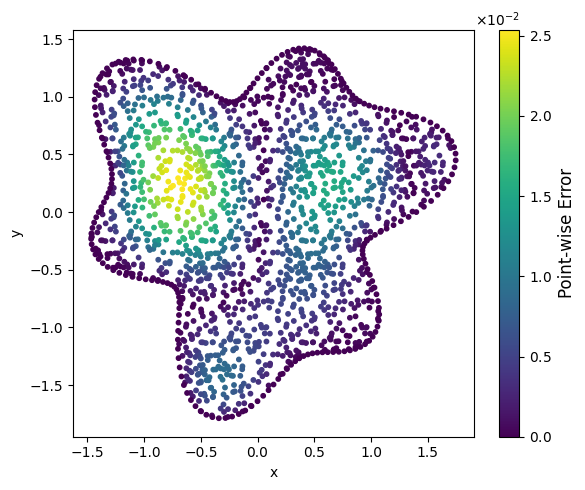

In [36]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(1, hidden_size, 1).to(device) #
Phi.initi()
Phi = Phi.double()


# # ===========================================================
u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)

torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 200
N_boundary = 200
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, ptch, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
X = np.vstack([X_inner, X_boundary])
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
M1 = Yin.shape[0]

#####
tau = 1e-3
T = 0.2 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

order = 3
reg = 1e-13
u_true = u_func(Y[:,0:1], Y[:,1:2],t)
scheme = "BDF2"
# # ===========================================================
if order == 0:
    U,LBDF1,LBDF2,LI = rfm_fd_pum_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg)
else:
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme=scheme)


error = np.abs(U - u_true)#/np.abs(u_true + 1e-6)
# print(error)
print(f'p = {order}; L infity error in u_rfmfd_pu: {error.max().item():.3e}')
error_u = np.linalg.norm(U - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'p = {order}; Relative L2 error in u_rfmfd_pu: {error_u.item():.3e}')

for i in range(Nt):
    err_time = np.linalg.norm(U[:,i].toarray().ravel() - u_true[:,i], 2) / np.linalg.norm(u_true[:,i], 2)
    print(f'Time step {i}, Relative L2 error: {err_time.item():.3e}')

UT = U[:,-1:].toarray().ravel()
u_true_T = u_true[:,-1:].squeeze(-1)

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UT - u_true_T), cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_pointwise.eps', bbox_inches='tight')
plt.show()

Compiling matrix cost 1.199983835220337 seconds.
cond(LI) = 1.0000050678387074
cond(LBDF1) = 75062809861.64484
cond(LBDF2) = 149567649011.2117
Solving linear system cost 1.4418058395385742 seconds.
p = 4; L infity error in u_rfmfd: 1.101e-02
p = 4; Relative L2 error in u_rfmfd: 2.821e-03
Time step 0, Relative L2 error: 0.000e+00
Time step 1, Relative L2 error: 3.043e-03
Time step 2, Relative L2 error: 3.059e-03
Time step 3, Relative L2 error: 3.050e-03
Time step 4, Relative L2 error: 3.048e-03
Time step 5, Relative L2 error: 3.045e-03
Time step 6, Relative L2 error: 3.043e-03
Time step 7, Relative L2 error: 3.040e-03
Time step 8, Relative L2 error: 3.038e-03
Time step 9, Relative L2 error: 3.036e-03
Time step 10, Relative L2 error: 3.033e-03
Time step 11, Relative L2 error: 3.031e-03
Time step 12, Relative L2 error: 3.028e-03
Time step 13, Relative L2 error: 3.026e-03
Time step 14, Relative L2 error: 3.024e-03
Time step 15, Relative L2 error: 3.021e-03
Time step 16, Relative L2 error: 

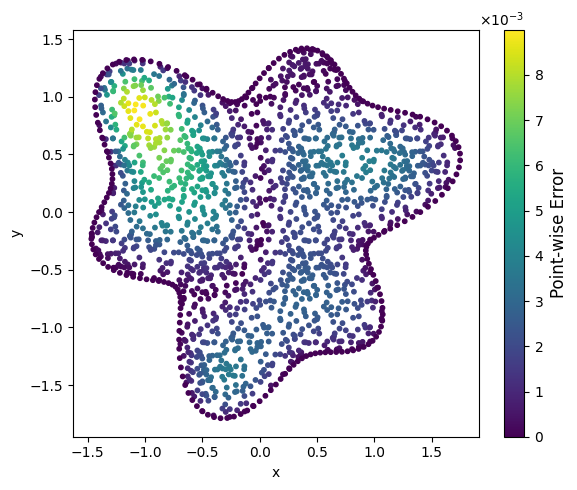

In [37]:
key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(1, hidden_size, 1).to(device) #
Phi.initi()

Phi = Phi.double()

# # ===========================================================
u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)

torchdtype = torch.float64
N_patch_grid = 5
N_local_per_patch = 200
N_boundary = 200
R_ptch = 0.8
mode = "c-rbf-pum"
# generate points
X_inner, X_boundary, ptch, _ , _ = generator_points_star(
N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
X = np.vstack([X_inner, X_boundary])
Yin = X_inner
Yb = X_boundary
Y = np.vstack([Yin, Yb])
M1 = Yin.shape[0]
h = fill_distance(X)

#####
tau = 1e-3
T = 0.2 

Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

order = 4
reg = 1e-12
u_true = u_func(Y[:,0:1], Y[:,1:2],t)

scheme = "BDF2"
# # ===========================================================
if order == 0:
    U,LBDF1,LBDF2,LI = rfm_fd_pum_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg)
else:
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme=scheme)


error = np.abs(U - u_true)#/np.abs(u_true + 1e-6)
# print(error)
print(f'p = {order}; L infity error in u_rfmfd: {error.max().item():.3e}')
error_u = np.linalg.norm(U - u_true, 2) / np.linalg.norm(u_true, 2)
print(f'p = {order}; Relative L2 error in u_rfmfd: {error_u.item():.3e}')

for i in range(Nt):
    err_time = np.linalg.norm(U[:,i].toarray().ravel() - u_true[:,i], 2) / np.linalg.norm(u_true[:,i], 2)
    print(f'Time step {i}, Relative L2 error: {err_time.item():.3e}')

UT = U[:,-1:].toarray().ravel()
u_true_T = u_true[:,-1:].squeeze(-1)

import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c=np.abs(UT - u_true_T), cmap='viridis', s=10)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
# plt.title(f'Augmented RFM-FD Point-wise Error (p = {order})')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_pointwise.eps', bbox_inches='tight')
plt.show()


# 画收敛阶段图

Run Q=1, N_local_per_patch=15
X.shape 136
fill_distance of X: 0.3444818172186383
cond(LI) = 1.0000004788090153
cond(LBDF1) = 47678141.933886826
cond(LBDF2) = 95351176.64448354
h = 3.445e-01, L2 error = 5.846e-02, 
Run Q=2, N_local_per_patch=30
X.shape 274
fill_distance of X: 0.20053933223375323
cond(LI) = 1.000000481626815
cond(LBDF1) = 62458894.86757496
cond(LBDF2) = 124902767.59485734
h = 2.005e-01, L2 error = 3.679e-02, 
Run Q=3, N_local_per_patch=70
X.shape 644
fill_distance of X: 0.14381952512412274
cond(LI) = 1.0000011297691411
cond(LBDF1) = 133478040.10845916
cond(LBDF2) = 266868451.9585142
h = 1.438e-01, L2 error = 2.992e-02, 
Run Q=4, N_local_per_patch=110
X.shape 1010
fill_distance of X: 0.11042607949991341
cond(LI) = 1.0000013156787488
cond(LBDF1) = 180662051.2571318
cond(LBDF2) = 361121813.6468846
h = 1.104e-01, L2 error = 2.817e-02, 
Run Q=5, N_local_per_patch=200
X.shape 1823
fill_distance of X: 0.07872309159537244
cond(LI) = 1.0000075462250189
cond(LBDF1) = 1074115418.05

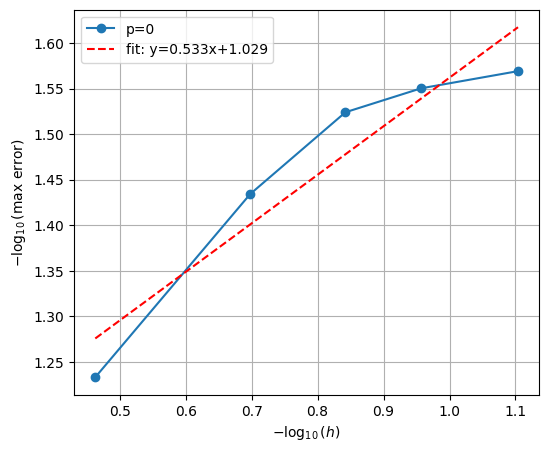

In [38]:
key = 100
np.random.seed(key)
H = np.zeros((5,5))
E = np.zeros((5,5))
NN = [15,30,70,110,200]
tau = 1e-3
T = 0.2 

Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)
scheme = "BDF2"
RR = [1e-12,1e-12,1e-12,1e-12,1e-13]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)

    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 0
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,LBDF1,LBDF2,LI = rfm_fd_pum_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg)
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
X.shape 136
Compiling matrix cost 0.05246281623840332 seconds.
cond(LI) = 1.0000004790403905
cond(LBDF1) = 46200072.41646824
cond(LBDF2) = 92395466.76256889
Solving linear system cost 0.02573108673095703 seconds.
h = 3.445e-01, L2 error = 5.921e-02, 
Run Q=2, N_local_per_patch=30
X.shape 274
Compiling matrix cost 0.05825304985046387 seconds.
cond(LI) = 1.000000481741523
cond(LBDF1) = 59162697.135665774
cond(LBDF2) = 118312125.17897159
Solving linear system cost 0.048108816146850586 seconds.
h = 2.005e-01, L2 error = 4.171e-02, 
Run Q=3, N_local_per_patch=70
X.shape 644
Compiling matrix cost 0.14864230155944824 seconds.
cond(LI) = 1.00000112968325
cond(LBDF1) = 129548113.5760222
cond(LBDF2) = 259014239.2104887
Solving linear system cost 0.14510512351989746 seconds.
h = 1.438e-01, L2 error = 3.550e-02, 
Run Q=4, N_local_per_patch=110
X.shape 1010
Compiling matrix cost 0.34241366386413574 seconds.
cond(LI) = 1.0000013155822869
cond(LBDF1) = 178126865.99425864

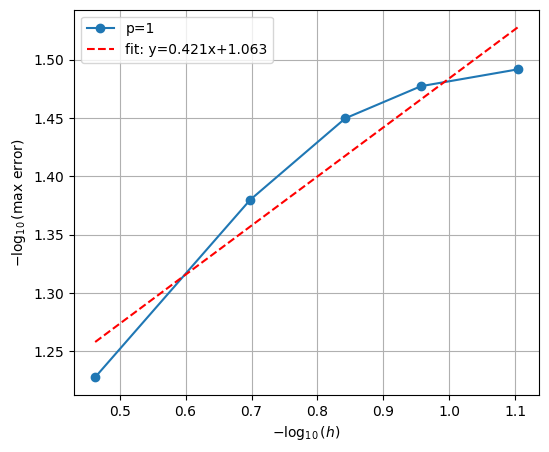

In [39]:
key = 100
np.random.seed(key)
NN = [15,30,70,110,200]
tau = 1e-3
T = 0.2 

Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)
scheme = "BDF2"
RR = [1e-12,1e-12,1e-12,1e-12,1e-13]
KK = [35, 45, 75, 120, 160]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, ptch, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    # C, R, info = generate_patches_star_2d(X,target_n=KK[qi],delta=0.2,safety=1.15,margin=0.05,max_iter=10)
    # ptch = {
    #     "C": C,
    #     "R": R
    # }   
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 1
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15
X.shape 136
Compiling matrix cost 0.07093071937561035 seconds.
cond(LI) = 1.0000004803850289
cond(LBDF1) = 82266422.26043491
cond(LBDF2) = 164514264.7364428
Solving linear system cost 0.026275157928466797 seconds.
h = 3.445e-01, L2 error = 2.716e-02, 
Run Q=2, N_local_per_patch=30
X.shape 274
Compiling matrix cost 0.06019186973571777 seconds.
cond(LI) = 1.0000004827184783
cond(LBDF1) = 91098092.83188465
cond(LBDF2) = 182167248.74427778
Solving linear system cost 0.04581260681152344 seconds.
h = 2.005e-01, L2 error = 1.836e-02, 
Run Q=3, N_local_per_patch=70
X.shape 644
Compiling matrix cost 0.1493816375732422 seconds.
cond(LI) = 1.000001128014478
cond(LBDF1) = 176092530.67974648
cond(LBDF2) = 352057407.62774
Solving linear system cost 0.14585661888122559 seconds.
h = 1.438e-01, L2 error = 1.730e-02, 
Run Q=4, N_local_per_patch=110
X.shape 1010
Compiling matrix cost 0.34090638160705566 seconds.
cond(LI) = 1.00000131374385
cond(LBDF1) = 230708311.986939
cond

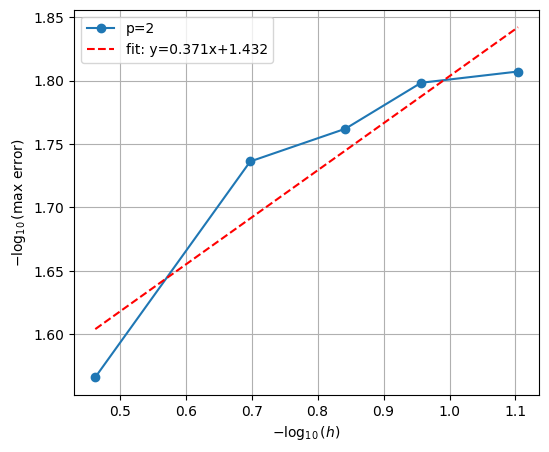

In [40]:
key = 100
np.random.seed(key)

NN = [15,30,70,110,200]
tau = 1e-3
T = 0.2 

Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

RR = [1e-12,1e-12,1e-12,1e-12,1e-13]
KK = [35, 45, 75, 80, 155]


for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, ptch, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    ## to change the patch number, you can regenerate the patches here by uncommenting the following code
    # C, R, info = generate_patches_star_2d(X,target_n=KK[qi],delta=0.2,safety=1.15,margin=0.05,max_iter=10)
    # ptch = {
    #     "C": C,
    #     "R": R
    # }

    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 2
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15

--- iter 0 ---
========== Patch report ==========
num patches: 14
R = 1.0166621330826102
uncovered X: 0 / 136
cover count min/mean/max: 1 2.2941176470588234 4
patch nX min/mean/max: 1 22.285714285714285 59
H = 1.19814781413049
target_n = 35
mean nX & target_n = 22.285714285714285 & 35
X.shape 136
Compiling matrix cost 0.0977180004119873 seconds.
cond(LI) = 1.000000610830984
cond(LBDF1) = 67130714.85151148
cond(LBDF2) = 134222314.58598393
Solving linear system cost 0.02570962905883789 seconds.
h = 3.445e-01, L2 error = 9.630e-03, 
Run Q=2, N_local_per_patch=30

--- iter 0 ---
========== Patch report ==========
num patches: 20
R = 0.7728909715776802
uncovered X: 0 / 274
cover count min/mean/max: 1 2.3686131386861313 4
patch nX min/mean/max: 3 32.45 76
H = 0.910860745200728
target_n = 45
mean nX & target_n = 32.45 & 45
X.shape 274


Compiling matrix cost 0.0529780387878418 seconds.
cond(LI) = 1.0000004675736927
cond(LBDF1) = 131765308.36884603
cond(LBDF2) = 263449415.71078095
Solving linear system cost 0.04278874397277832 seconds.
h = 2.005e-01, L2 error = 6.681e-03, 
Run Q=3, N_local_per_patch=70

--- iter 0 ---
========== Patch report ==========
num patches: 26
R = 0.6335407154037743
uncovered X: 0 / 644
cover count min/mean/max: 1 2.222049689440994 4
patch nX min/mean/max: 1 55.03846153846154 115
H = 0.7466348933663091
target_n = 75
mean nX & target_n = 55.03846153846154 & 75
X.shape 644
Compiling matrix cost 0.10473108291625977 seconds.
cond(LI) = 1.0000008556020683
cond(LBDF1) = 2188144121.390138
cond(LBDF2) = 4374716769.584606
Solving linear system cost 0.11207103729248047 seconds.
h = 1.438e-01, L2 error = 6.417e-03, 
Run Q=4, N_local_per_patch=110

--- iter 0 ---
========== Patch report ==========
num patches: 26
R = 0.6412291069905793
uncovered X: 0 / 1010
cover count min/mean/max: 1 2.228712871287129 4
p

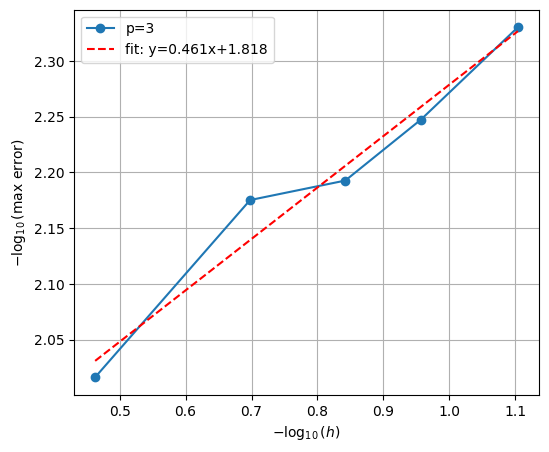

In [41]:
key = 100
np.random.seed(key)

NN = [15,30,70,110,200]
tau = 1e-3
T = 0.2 

Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)
RR = [1e-12,1e-12,1e-12,1e-13,1e-14]
KK = [35, 45, 75, 120, 120]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = n_local
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, ptch, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    ## to make the result more stable, you can regenerate the patches here by uncommenting the following code
    C, R, info = generate_patches_star_2d(X,target_n=KK[qi],delta=0.2,safety=1.15,margin=0.05,max_iter=10)
    ptch = {
        "C": C,
        "R": R
    }

    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 3
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


Run Q=1, N_local_per_patch=15

--- iter 0 ---
========== Patch report ==========
num patches: 13
R = 1.0950474395834107
uncovered X: 0 / 136
cover count min/mean/max: 1 2.3455882352941178 4
patch nX min/mean/max: 3 24.53846153846154 65
H = 1.2905257837506598
target_n = 40
mean nX & target_n = 24.53846153846154 & 40
X.shape 136
Compiling matrix cost 0.04189181327819824 seconds.
cond(LI) = 1.0000006582614296
cond(LBDF1) = 98168868.31449671
cond(LBDF2) = 195546512.9594252
Solving linear system cost 0.027397871017456055 seconds.
h = 3.445e-01, L2 error = 1.390e-02, 
Run Q=2, N_local_per_patch=30

--- iter 0 ---
========== Patch report ==========
num patches: 20
R = 0.7728909715776802
uncovered X: 0 / 274
cover count min/mean/max: 1 2.3686131386861313 4
patch nX min/mean/max: 3 32.45 76
H = 0.910860745200728
target_n = 45
mean nX & target_n = 32.45 & 45
X.shape 274
Compiling matrix cost 0.05396866798400879 seconds.
cond(LI) = 1.0000004691072673
cond(LBDF1) = 915327365.0485196
cond(LBDF2) = 

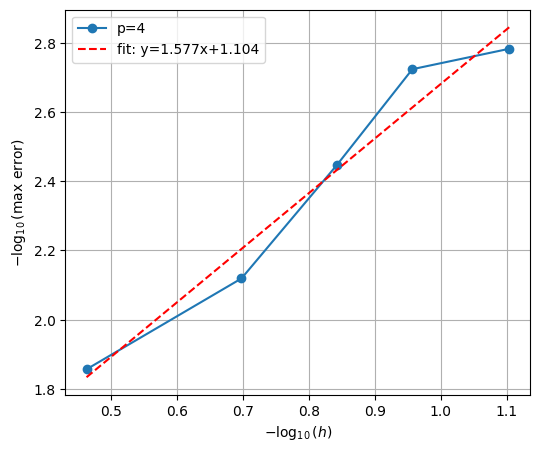

In [42]:
key = 100
np.random.seed(key)

NN = [15,30,70,110,200]
# BC = [35,31,70,110,200] # if not wana regenerate the patches, you can use this BC to make the result more stable
BC = [15,30,70,110,200]

tau = 1e-3
T = 0.2 

Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

KK = [40, 45, 65, 130, 165]
RR = [1e-12,1e-12,1e-12,1e-12,1e-14]

for qi, n_local in enumerate(NN):
    print(f'Run Q={qi+1}, N_local_per_patch={n_local}')
    N_patch_grid = 5
    N_local_per_patch = n_local
    N_boundary = BC[qi]
    R_ptch = 0.8
    mode = "c-rbf-pum"
    # generate points
    X_inner, X_boundary, _, _ ,_ = generator_points_star(
    N_patch_grid, N_local_per_patch, N_boundary, R_ptch, mode)
    # assemble X,Y
    X = np.vstack([X_inner, X_boundary])
    ## to make the result more stable, you can regenerate the patches here by uncommenting the following code
    C, R, info = generate_patches_star_2d(X,target_n=KK[qi],delta=0.2,safety=1.15,margin=0.05,max_iter=10)
    ptch = {
        "C": C,
        "R": R
    }
    Yin = X_inner
    Yb = X_boundary
    print(f"X.shape",X.shape[0])
    Y = np.vstack([Yin, Yb])
    order = 4
    h = fill_distance(X)
    H[order,qi] = h
    reg = RR[qi]
    u_true = u_func(Y[:,0:1], Y[:,1:2],t)
    U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme="BDF2")
    error = np.max(np.abs(U - u_true))
    e = np.linalg.norm(U - u_true, 'fro') / np.linalg.norm(u_true, 'fro')
    E[order,qi] = e
    print(f'h = {h:.3e}, L2 error = {e:.3e}, ')


x = -np.log10(H[order,:])
y = -np.log10(E[order,:])
mask = np.isfinite(x) & np.isfinite(y)
if np.count_nonzero(mask) >= 2:
    slope, intercept = np.polyfit(x[mask], y[mask], 1)
    print(f'slope = {slope:.6f}, bias = {intercept:.6f}')
    xx = np.linspace(x[mask].min(), x[mask].max(), 100)
    yy = slope * xx + intercept
    plt.figure(figsize=(6,5))
    plt.plot(x, y, marker='o', linestyle='-', label=f'p={order}')
    plt.plot(xx, yy, 'r--', label=f'fit: y={slope:.3f}x+{intercept:.3f}')
    # plt.plot(xx, yy, 'r--', label='')
    plt.xlabel(r'$- \log_{10}(h)$')
    plt.ylabel(r'$- \log_{10}(\mathrm{max\ error})$')
    plt.legend()
    plt.grid(True)
    # plt.title('p = 1, Convergence scatter and linear fitting ')
    # plt.savefig(f'./result/p={order}_convergence_scatter.eps', bbox_inches='tight')
    plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


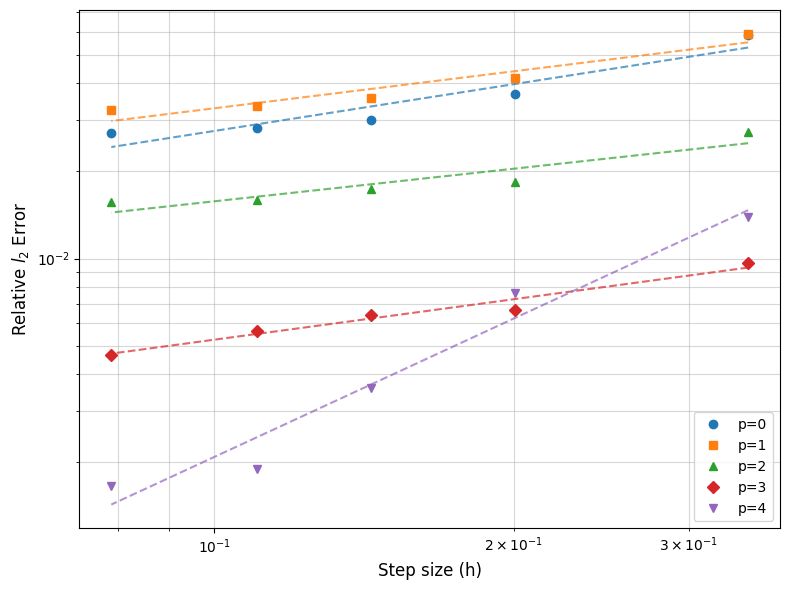

In [43]:
markers = ['o', 's', '^', 'D', 'v']  
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
labels = ['p=0', 'p=1', 'p=2', 'p=3','p=4']
plt.figure(figsize=(8, 6))

for i in range(5):
    h = H[i, :]
    e = E[i, :]
    log_h = np.log(h)
    log_e = np.log(e)
    slope, intercept = np.polyfit(log_h, log_e, 1)
    fit_e = np.exp(intercept) * h**slope
    plt.loglog(h, e, markers[i], color=colors[i], label=f'{labels[i]}')
    plt.loglog(h, fit_e, linestyle='--', color=colors[i], alpha=0.7)
    # plt.plot(h, e, marker=markers[i], color=colors[i], linestyle='-', label=f'{labels[i]}')

plt.xlabel('Step size (h)', fontsize=12)
plt.ylabel('Relative $l_2$ Error', fontsize=12)
# plt.title('Convergence Study: Least Squares Fit', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('./result/heat_rfmfd_pu_p=0123_convergence_scatter.eps', bbox_inches='tight')
plt.show()

$Operator learning$

In [12]:

import torch
import numpy as np
import torch.nn as nn
from scipy.io import loadmat
import scipy.sparse as sp
from scipy.spatial import cKDTree, distance
from scipy.linalg import cholesky
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

dtype = torch.float64
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
from scipy.stats import qmc

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)
# =========================================================
# 1. 2D star-shaped boundary
# =========================================================
def r_max_func(theta):
    return 2.0 * (0.7 + 0.12 * (np.sin(6 * theta) + np.sin(3 * theta)))


# =========================================================
# 2. inside test
# =========================================================
def inside_star_2d(x, y, eps=1e-12):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    theta = np.where(theta < 0, theta + 2 * np.pi, theta)
    return r <= r_max_func(theta) + eps


# =========================================================
# 3. unique points
# =========================================================
def unique_points_by_tol(X, tol=1e-10):
    X = np.asarray(X, dtype=np.float64)
    Xq = np.round(X / tol).astype(np.int64)
    _, idx = np.unique(Xq, axis=0, return_index=True)
    idx = np.sort(idx)
    return X[idx]


# =========================================================
# 4. generate boundary points
# =========================================================
def generate_boundary_points_2d(N_boundary=1000):
    theta = np.linspace(0.0, 2 * np.pi, N_boundary, endpoint=False)
    r = r_max_func(theta)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return np.vstack([x, y]).T


# =========================================================
# 5. generate patch centers and H
# =========================================================
def generate_centers_auto_H_2d(N_patch_grid, margin=0.1):
    """
    Generate Cartesian patch centers from the bounding box of the 2D star domain.

    Returns
    -------
    C : ndarray, shape (N_patch_grid^2, 2)
        Raw patch centers.

    H : float
        max(Hx, Hy).
    """
    theta = np.linspace(0.0, 2 * np.pi, 4000, endpoint=False)
    r = r_max_func(theta)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    # 这里 margin 和你 3D 代码一致，是绝对外扩量，不是比例
    x_min = x.min() - margin
    x_max = x.max() + margin
    y_min = y.min() - margin
    y_max = y.max() + margin

    Hx = (x_max - x_min) / (N_patch_grid - 1)
    Hy = (y_max - y_min) / (N_patch_grid - 1)
    H = max(Hx, Hy)

    Cx = np.linspace(x_min, x_max, N_patch_grid)
    Cy = np.linspace(y_min, y_max, N_patch_grid)

    Xg, Yg = np.meshgrid(Cx, Cy, indexing="ij")
    C = np.vstack([Xg.ravel(), Yg.ravel()]).T

    return C, H


def compute_R_from_H_delta_2d(H, delta):
    """
    In 2D, a square cell of spacing H is covered by a disk radius sqrt(2)*H/2.
    Add overlap factor delta:

        R = (1 + delta) * sqrt(2) * H / 2.
    """
    return (1.0 + delta) * np.sqrt(2.0) * H / 2.0


# =========================================================
# 6. generate inner points via patch disks + filter to domain
# =========================================================
def generate_inner_points_2d(C, R, N_local):
    """
    For each patch center c, generate N_local Halton points uniformly in disk B(c,R),
    then keep only points inside the star-shaped domain.
    """
    X_list = []

    for c in C:
        sampler = qmc.Halton(d=2, scramble=False)
        pts = sampler.random(N_local)

        u = pts[:, 0]
        v = pts[:, 1]

        theta = 2 * np.pi * u
        rr = R * np.sqrt(v)

        x = c[0] + rr * np.cos(theta)
        y = c[1] + rr * np.sin(theta)

        X_list.append(np.vstack([x, y]).T)

    X_raw = np.vstack(X_list)

    mask = inside_star_2d(X_raw[:, 0], X_raw[:, 1])
    X_inner = X_raw[mask]

    return X_inner


# =========================================================
# 7. remove empty patches
# =========================================================
def remove_empty_patches_by_Xinner_2d(C_raw, R, X_inner):
    """
    Remove patches that contain no interior points.

    Parameters
    ----------
    C_raw : ndarray, shape (Np,2)
    R : scalar or ndarray
    X_inner : ndarray, shape (N,2)

    Returns
    -------
    C_new : ndarray, shape (Np_new,2)
    R_new : ndarray, shape (Np_new,)
    keep : ndarray, bool
    nX : ndarray, shape (Np,)
    """
    C_raw = np.asarray(C_raw, dtype=np.float64)
    X_inner = np.asarray(X_inner, dtype=np.float64)

    if np.isscalar(R):
        R_vec = np.full(C_raw.shape[0], R, dtype=np.float64)
    else:
        R_vec = np.asarray(R, dtype=np.float64)

    tree_X = cKDTree(X_inner)

    keep = np.zeros(C_raw.shape[0], dtype=bool)
    nX = np.zeros(C_raw.shape[0], dtype=int)

    for j, c in enumerate(C_raw):
        idx = tree_X.query_ball_point(c, R_vec[j])
        nX[j] = len(idx)
        keep[j] = nX[j] > 0

    C_new = C_raw[keep]
    R_new = R_vec[keep]

    print(f"original patches: {C_raw.shape[0]}")
    print(f"kept patches: {C_new.shape[0]}")
    print(f"removed patches: {C_raw.shape[0] - C_new.shape[0]}")

    if np.any(keep):
        print(
            "patch nX min/mean/max: "
            f"{nX[keep].min()} / {nX[keep].mean():.2f} / {nX[keep].max()}"
        )
    else:
        print("No patches kept!")

    return C_new, R_new, keep, nX


# =========================================================
# 8. fill distance
# =========================================================
def fill_distance(nodes):
    nodes = np.asarray(nodes, dtype=np.float64)

    if nodes.shape[0] <= 1:
        return 0.0

    tree = cKDTree(nodes)
    dists, _ = tree.query(nodes, k=2, workers=-1)

    return np.float64(np.max(dists[:, 1]))


# =========================================================
# 9. coverage diagnostics
# =========================================================
def patch_cover_stats_2d(C, R, X):
    """
    Count how many patches cover each point in X.
    """
    C = np.asarray(C, dtype=np.float64)
    X = np.asarray(X, dtype=np.float64)

    if np.isscalar(R):
        R_vec = np.full(C.shape[0], R, dtype=np.float64)
    else:
        R_vec = np.asarray(R, dtype=np.float64)

    cover = np.zeros(X.shape[0], dtype=int)

    for j, c in enumerate(C):
        tree = cKDTree(X)
        idx = tree.query_ball_point(c, R_vec[j])
        cover[idx] += 1

    return {
        "cover_min": int(cover.min()),
        "cover_mean": float(cover.mean()),
        "cover_max": int(cover.max()),
        "uncovered": int(np.sum(cover == 0)),
        "cover": cover,
    }


# =========================================================
# 10. visualization
# =========================================================
def visualize_points_2d(X_inner, X_boundary, C=None, R=None):
    theta = np.linspace(0.0, 2 * np.pi, 1000, endpoint=False)
    rb = r_max_func(theta)

    xb = rb * np.cos(theta)
    yb = rb * np.sin(theta)

    plt.figure(figsize=(7, 7))
    ax = plt.gca()

    ax.plot(xb, yb, "k-", linewidth=1.0, label="Boundary curve")

    if C is not None and R is not None:
        R_vec = R if not np.isscalar(R) else np.full(len(C), R)
        th = np.linspace(0, 2 * np.pi, 200)
        for j, c in enumerate(C):
            ax.plot(
                c[0] + R_vec[j] * np.cos(th),
                c[1] + R_vec[j] * np.sin(th),
                "k:",
                linewidth=0.6,
                alpha=0.5,
            )
        ax.scatter(C[:, 0], C[:, 1], s=20, marker="x", color="green", label="Patch centers")

    if X_inner.shape[0] > 0:
        ax.scatter(
            X_inner[:, 0],
            X_inner[:, 1],
            s=8,
            color="red",
            alpha=0.7,
            label="Interior points",
        )

    if X_boundary.shape[0] > 0:
        ax.scatter(
            X_boundary[:, 0],
            X_boundary[:, 1],
            s=10,
            color="blue",
            alpha=0.8,
            label="Boundary points",
        )

    ax.set_aspect("equal", "box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, linewidth=0.4, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 11. main generator
# =========================================================
def generator_points_2d_overlap(
    N_patch_grid,
    N_local_per_patch,
    N_boundary,
    overlap,
    visu=True,
):
    """
    2D overlap version
    Parameters
    ----------
    N_patch_grid : int
        Number of patch centers per dimension.
    N_local_per_patch : int
        Number of Halton samples generated in each raw patch disk.
    N_boundary : int
        Number of boundary points.
    overlap : float
            R = (1+overlap)*sqrt(2)*H/2.
    visu : bool
        Whether to visualize.

    Returns
    -------
    X_inner : ndarray, shape (N_inner,2)
    X_boundary : ndarray, shape (N_boundary,2)
    C : ndarray, shape (Np,2)
    R : ndarray, shape (Np,)
    info : dict
    """

    X_boundary = generate_boundary_points_2d(N_boundary)
    X_boundary = unique_points_by_tol(X_boundary, tol=1e-10)

    # 1. raw centers
    C_raw, H = generate_centers_auto_H_2d(N_patch_grid, margin=0.1)

    # 2D local fill-distance estimate
    h = H / np.sqrt(N_local_per_patch)

    info = {
        "H": H,
        "h": h,
    }

    print("Generator's raw C:", len(C_raw))

    # 2. compute R from overlap
    R_scalar = compute_R_from_H_delta_2d(H, overlap)
    print("Generator's R =", R_scalar)

    # 3. generate inner points and filter centers
    X_inner = generate_inner_points_2d(C_raw, R_scalar, N_local_per_patch)
    X_inner = unique_points_by_tol(X_inner, tol=1e-10)

    C, R, _, _ = remove_empty_patches_by_Xinner_2d(C_raw, R_scalar, X_inner)

    print("X_inner:", len(X_inner))
    print("X_boundary:", len(X_boundary))

    # 4. coverage stats for X_inner and all X
    stat_inner = patch_cover_stats_2d(C, R, X_inner)
    X_all = np.vstack([X_inner, X_boundary])
    stat_all = patch_cover_stats_2d(C, R, X_all)

    print(
        "cover X_inner min/mean/max:",
        stat_inner["cover_min"],
        f"{stat_inner['cover_mean']:.2f}",
        stat_inner["cover_max"],
        "uncovered:",
        stat_inner["uncovered"],
    )

    print(
        "cover X_all min/mean/max:",
        stat_all["cover_min"],
        f"{stat_all['cover_mean']:.2f}",
        stat_all["cover_max"],
        "uncovered:",
        stat_all["uncovered"],
    )

    info.update({
        "R": R_scalar,
        "num_raw_patches": len(C_raw),
        "num_patches": len(C),
        "N_inner": len(X_inner),
        "N_boundary": len(X_boundary),
        "cover_inner_min": stat_inner["cover_min"],
        "cover_inner_mean": stat_inner["cover_mean"],
        "cover_inner_max": stat_inner["cover_max"],
        "cover_inner_uncovered": stat_inner["uncovered"],
        "cover_all_min": stat_all["cover_min"],
        "cover_all_mean": stat_all["cover_mean"],
        "cover_all_max": stat_all["cover_max"],
        "cover_all_uncovered": stat_all["uncovered"],
    })
    # 5. visualization
    if visu:
        visualize_points_2d(X_inner, X_boundary, C=C, R=R)
    return X_inner, X_boundary, C, R, info



class PhiNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PhiNet, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.input_layer = nn.Linear(input_size, hidden_size, bias = True)
        self.hidden_layer = nn.Linear(hidden_size, hidden_size, bias = True)
        self.output_layer = nn.Linear(hidden_size, output_size, bias = True) 
	
    def forward(self, x): # r : (K,1)  or (K,K)
        K = x.shape[0]
        if x.shape[-1] != self.input_size:
            x = x.view(-1, self.input_size)
        output = self.input_layer(x)
        output = torch.sin(output)
        output = torch.cos(self.hidden_layer(output))
        output = self.output_layer(output)
        if output.shape[0] != K:
            output = output.view(K, -1)
        return output
	
    def initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    # nn.init.normal_(m.bias, mean=0.0, std=1)
                    # m.bias.data.zero_()
                    nn.init.uniform_(m.bias, -0, 0)




In [13]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import spsolve
from scipy.linalg import cholesky, solve_triangular

def relative_l2(u_pred, u_true):
# Relative L2 error between two (N, 1) tensors.
    eps = 0
    def to_numpy(u):
        if sp.issparse(u):
            u = u.toarray()
        else:
            u = np.asarray(u)
        return u.reshape(-1) # flatten to (N,)
    u_pred,u_true = to_numpy(u_pred),to_numpy(u_true)
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + eps)


def build_wls_solver(A, reg=1e-12):
    """
    Precompute WLS system for repeated RHS solves.
    """

    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")

    A = A.tocsr()
    M, N = A.shape
    # -------------------------------------------------
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 10.0 / (row_max + 1e-12)
    W = sp.diags(w, format='csr')

    # -------------------------------------------------
    # precompute matrices
    # -------------------------------------------------
    Aw = W @ A
    AtA = Aw.T @ Aw + reg * sp.eye(N, format='csr')

    # factorization (FAST SOLVE)
    solver = spla.factorized(AtA.tocsc())

    # -------------------------------------------------
    # return closure
    # -------------------------------------------------
    def solve(RHS):
        """
        RHS: (M,K)
        """
        RHS = np.asarray(RHS, dtype=np.float64)

        if RHS.ndim == 1:
            RHS = RHS[:, None]

        # weighted RHS
        RHSw = w[:, None] * RHS

        Atb = Aw.T @ RHSw
        x = solver(Atb)

        if x.ndim == 1:
            x = x[:, None]

        return x

    return solve

def test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, u0_func,
                Yin, Yb, t, tau,
                scheme="BDF2"):
    """
    Multi-batch heat solver using unified WLS (row-max weighted least squares).

    Returns
    -------
    U : ndarray, shape (n_batch, M, NT)
    """

    # --------------------------------------------------
    # geometry
    # --------------------------------------------------
    Y = np.concatenate([Yin, Yb], axis=0)
    M = Y.shape[0]
    M2 = Yb.shape[0]
    M1 = M - M2
    NT = t.shape[0]

    # --------------------------------------------------
    # data
    # --------------------------------------------------
    f_val = f_func(Yin[:, 0:1], Yin[:, 1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:, 0:1], Yb[:, 1:2], t) if callable(g_func) else g_func

    u0 = u0_func(Y[:, 0:1], Y[:, 1:2]) if callable(u0_func) else u0_func
    u0 = np.asarray(u0, dtype=np.float64)

    # --------------------------------------------------
    # batch handling
    # --------------------------------------------------
    if u0.ndim == 1:
        u0 = u0[:, None]

    n_batch = u0.shape[1]

    solve_LBDF1 = build_wls_solver(LBDF1, reg=1e-12)
    solve_LBDF2 = build_wls_solver(LBDF2, reg=1e-12)
    solve_LI    = build_wls_solver(LI, reg=1e-12)

    # --------------------------------------------------
    # initial solve (LI)
    # --------------------------------------------------
    alpha_0 = solve_LI(u0)

    # --------------------------------------------------
    # storage
    # --------------------------------------------------
    U = np.zeros((n_batch, M, NT), dtype=np.float64)
    U[:, :, 0] = u0.T
    U[:, M1:, :] = g_val[None, :, :]

    reg = 1e-12

    # ==================================================
    # BDF1
    # ==================================================
    if scheme == "BDF1":

        for i in range(0, NT - 1):

            rhs_int = LI @ alpha_0
            if rhs_int.ndim == 1:
                rhs_int = rhs_int[:, None]

            rhs = rhs_int[:M1, :] + tau * f_val[:, i + 1:i + 2]

            RHS = np.vstack([
                rhs,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_1, _ = solve_LBDF1(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_1).T

            alpha_0 = alpha_1

        return U
    # ==================================================
    # BDF2
    # ==================================================
    elif scheme == "BDF2":

        # -----------------------------
        # step 1: initial BDF1 step
        # -----------------------------
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]

        RHS = np.vstack([
            rhs_int,
            np.repeat(g_val[:, 1:2], n_batch, axis=1)
        ])

        alpha_1 = solve_LBDF1(RHS)

        U[:, :M1, 1] = (LI[:M1, :] @ alpha_1).T

        # -----------------------------
        # BDF2 time loop
        # -----------------------------
        for i in range(1, NT - 1):

            rhs_int = (
                LI[:M1, :] @ (4 * alpha_1 - alpha_0)
                + 2 * tau * f_val[:, i + 1:i + 2]
            )

            RHS = np.vstack([
                rhs_int,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_2 = solve_LBDF2(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_2).T
            U[:, M1:, i + 1] = g_val[:, i + 1]

            alpha_0 = alpha_1
            alpha_1 = alpha_2

        return U

    else:
        raise ValueError("Unsupported scheme. Use 'BDF1' or 'BDF2'.")
    


In [14]:
### rewrite the solver for weighted QR
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import time

def rfm_fd_pum_poly_solve_heat_QR(
        ptch, X, Yin, Yb, t, tau,
        f_func, g_func, u0_func,
        Phi, reg, order,
        scheme="BDF2"
):
    """
    PUM-RFM-FD heat solver with pre-factorized weighted least squares.

    Returns
    -------
    U      : (M, NT)
    LBDF1  : sparse matrix
    LBDF2  : sparse matrix
    LI     : sparse matrix
    """
    patch_C = ptch['C']
    patch_R = ptch['R']
    Nc = patch_C.shape[0]
    Norder = (order + 1) * (order + 2) // 2  # number of polynomial basis in 2D
    # Combine evaluation points
    Y = np.concatenate([Yin, Yb], axis=0)
    # Compute distance to all source points
    M = Y.shape[0]
    N = X.shape[0]
    M2 = Yb.shape[0] # number of boundary points
    M1 = M - M2
    NT = t.shape[0]
    W_matrix,grad_Wx, grad_Wy, lap_W = shepard_weights_with_derivatives(Y, patch_C, patch_R)  # M x Nc
    # Construct sparse L matrix
    LBDF2 = lil_matrix((M, N))
    LI = lil_matrix((M, N))
    LBDF1 = lil_matrix((M, N))
    LBDF3 = lil_matrix((M, N))
    LBDF4 = lil_matrix((M, N))
    # Construct RHS
    RHS = np.zeros((M,1))
    # Precompute RHS
    f_val = f_func(Yin[:,0:1], Yin[:,1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:,0:1], Yb[:,1:2], t) if callable(g_func) else g_func
    u0 = u0_func(Y[:,0:1], Y[:,1:2]) if callable(u0_func) else u0_func[:, None]

    
    # --------------------------
    # 预处理邻域索引（vectorized）
    # --------------------------
    dist_XC = cdist(X, patch_C)      # (N, Nc)
    dist_YC = cdist(Y, patch_C)      # (M, Nc)
    time_start = time.time()
    # --------------------------------------------------
    for i in range(Nc):
        idx_X = np.where(dist_XC[:, i] <= patch_R[i])[0]
        idx_Y = np.where(dist_YC[:, i] <= patch_R[i])[0]
        idx_Yin = idx_Y[idx_Y < M1]
        idx_Yb = idx_Y[idx_Y >= M1]

        Mk,Mk_1 = idx_Y.shape[0],idx_Yin.shape[0]
        Yk_in,Yk_b = Y[idx_Yin],Y[idx_Yb]
        Yk = np.concatenate([Yk_in,Yk_b], axis = 0)
        nj = idx_X.shape[0]
        RHS_lap = np.zeros((nj+Norder,Mk_1)) # only need interior points
        RHS_ide = np.ones((nj+Norder,Mk))
        AP = np.zeros((nj+Norder,nj+Norder))
        P = np.ones((nj,Norder))

        Z = X[idx_X] # (nj,2)
        h_local = patch_R[i]
        xc = patch_C[i]
        Z = (Z - xc[None, :]) / h_local
        Yk = (Yk - xc[None, :]) / h_local
        Yk_in = (Yk_in - xc[None, :]) / h_local

        dist_ZZ = distance.cdist(Z, Z, metric='euclidean') # (nj,nj)
        dist_ZZ = torch.as_tensor(dist_ZZ, dtype = torch.float64, device = device)
        Phi_jj = Phi(dist_ZZ) # (nj,nj)
        Phi_jj = Phi_jj.detach().cpu().numpy()
        phi_YX, lap_phi, grad_y  = laplacian_phi_wrt_y(Phi, Yk, Z, eps=1e-8) # (Mk,nj)
        lap_phi = lap_phi/ h_local**2
        grad_y = grad_y / h_local

        grad_phi_x = grad_y[:, :, 0].T  # (nj,Mk)
        grad_phi_y = grad_y[:, :, 1].T  # (nj,Mk) (Mk,nj) # if not Yk, storage will be too large.
        # AP
        P = poly2D(Z, order)  # (nj,Norder)
        AP[:nj,:] = np.concatenate([Phi_jj,P], axis = 1) # (nj,nj+Norder)
        AP[nj:,:-Norder] = P.T # (Norder,nj)
        ## --- RHS_lap(Yin), RHS_ide(Y)
        lap_p = laplacian_poly2D(order,Yk_in) # (Norder, Mk_1)
        lap_p = lap_p / h_local**2
        p_y = poly2D(Yk, order).T       # (Mk,Norder).T = (Norder,Mk)

        lap_phi = lap_phi[:Mk_1,:]      # (Mk,nj) --> (Mk_1,nj)
        RHS_lap[:nj,:] = lap_phi.T      # (nj, Mk_1), Yk_in
        RHS_lap[nj:,:] = lap_p          # (Norder, Mk_1)
        RHS_ide[:nj,:] = phi_YX.T       # (Mk,nj).T 
        RHS_ide[nj:,:] = p_y            # (Norder, Mk)
        # --- RHS_gra_x(Yin), RHS_gra_z(Yin)
        p_x,p_z = gradient_poly2D(order, Yk_in)  # (Norder,Mk_1)
        p_x = p_x / h_local
        p_z = p_z / h_local
        RHS_gra_x = np.zeros((nj+Norder,Mk_1))  # (nj+Norder, Mk_1)
        RHS_gra_z = np.zeros((nj+Norder,Mk_1))  # (nj+Norder, Mk_1)
        RHS_gra_x[:nj,:] = grad_phi_x[:,:Mk_1]     # (nj, Mk_1)
        RHS_gra_z[:nj,:] = grad_phi_y[:,:Mk_1]     # (nj, Mk_1)
        RHS_gra_x[nj:,:] = p_x               # (Norder, Mk_1)
        RHS_gra_z[nj:,:] = p_z               # (Norder, Mk_1)

        # --- w_lap, w_ide
        AP = AP + reg * np.eye(nj + Norder)

        LU = lu_factor(AP)
        # RHS_all = np.concatenate([RHS_ide, RHS_lap],axis=1)
        RHS_all = np.concatenate([RHS_ide, RHS_lap, RHS_gra_x, RHS_gra_z],axis=1)
        W_all = lu_solve(LU, RHS_all)
        w_ide    = W_all[:, 0:Mk]                # (nj + Norder, Mk)
        w_lap    = W_all[:, Mk:Mk+Mk_1]          # (nj + Norder, Mk_1)
        w_grad_x = W_all[:, Mk+Mk_1:Mk+2*Mk_1]   # (nj + Norder, Mk_1)
        w_grad_z = W_all[:, Mk+2*Mk_1:]          # (nj + Norder, Mk_1)

        # --- Shepard weight. W_matrix,grad_Wx, grad_Wy, lap_W , M x Nc
        win = W_matrix[idx_Yin,i][None, :]    # (1, Mk_1)
        win_gradx = grad_Wx[idx_Yin,i][None, :]  # (1, Mk_1)
        win_gradz = grad_Wy[idx_Yin,i][None, :]  # (1, Mk_1)
        win_lap = lap_W[idx_Yin,i][None, :]      # (1, Mk_1)
        # Laplace = win * w_lap[:nj,:Mk_1]
        Laplace = (2 * win_gradx * w_grad_x[:nj,:Mk_1] + 2 * win_gradz * w_grad_z[:nj,:Mk_1] + win * w_lap[:nj,:Mk_1] + win_lap * w_ide[:nj,:Mk_1])  # (nj, Mk_1)
        I = win * w_ide[:nj,:Mk_1]          # (nj, Mk_1)
        # --- boundary condtion
        wbc = W_matrix[idx_Yb,i][None, :]  # (1, Mk_2)
        Op_bc = wbc * w_ide[:nj,Mk_1:]        # (nj, Mk_2)
        # --- LI 
        wvec = W_matrix[idx_Y, i][None, :]    # (1, Mk)
        IDE = wvec * w_ide[:nj,:]             # (nj,Mk)
        # --- Iterative Matrix
        if scheme == 'BDF2':
            LBDF1[np.ix_(idx_Yin, idx_X)] = LBDF1[np.ix_(idx_Yin, idx_X)] + (I -  tau * Laplace).T
            LBDF2[np.ix_(idx_Yin, idx_X)] = LBDF2[np.ix_(idx_Yin, idx_X)] + (3 * I - 2 * tau * Laplace).T

            LBDF1[np.ix_(idx_Yb, idx_X)] = LBDF1[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF2[np.ix_(idx_Yb, idx_X)] = LBDF2[np.ix_(idx_Yb, idx_X)] + Op_bc.T
                
            LI[np.ix_(idx_Y,idx_X)] = LI[np.ix_(idx_Y,idx_X)] + IDE.T
        elif scheme == 'BDF4':    
            LBDF1[np.ix_(idx_Yin, idx_X)] = LBDF1[np.ix_(idx_Yin, idx_X)] + (I -  tau * Laplace).T
            LBDF2[np.ix_(idx_Yin, idx_X)] = LBDF2[np.ix_(idx_Yin, idx_X)] + (3 * I - 2 * tau * Laplace).T
            LBDF3[np.ix_(idx_Yin, idx_X)] = LBDF3[np.ix_(idx_Yin, idx_X)] + (11 * I - 6 * tau * Laplace).T
            LBDF4[np.ix_(idx_Yin, idx_X)] = LBDF4[np.ix_(idx_Yin, idx_X)] + (25 * I - 12 * tau * Laplace).T

            LBDF1[np.ix_(idx_Yb, idx_X)] = LBDF1[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF2[np.ix_(idx_Yb, idx_X)] = LBDF2[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF3[np.ix_(idx_Yb, idx_X)] = LBDF3[np.ix_(idx_Yb, idx_X)] + Op_bc.T
            LBDF4[np.ix_(idx_Yb, idx_X)] = LBDF4[np.ix_(idx_Yb, idx_X)] + Op_bc.T
                
            LI[np.ix_(idx_Y,idx_X)] = LI[np.ix_(idx_Y,idx_X)] + IDE.T
        else:
            raise ValueError("Unsupported mode. Use 'BDF2' or 'BDF4'.")    
    # ===========================================================
    # Solve linear system L U = RHS
    # ===========================================================
    time_end = time.time()
    print(f"Compile matrix takes: {time_end - time_start:.4f} seconds")
    U = lil_matrix((M, NT))
    U[:,0:1] = u0   # (N,1)
    U[M1:,:] = g_val
    LI = LI.tocsr()
    LBDF1 = LBDF1.tocsr()
    LBDF2 = LBDF2.tocsr()

    if M == N:
        cond_LI = np.linalg.cond(LI.todense())
        print("cond(LI) = ", cond_LI)

    # --------------------------------------------------
    # WLS pre-factorization
    # --------------------------------------------------
    solve_LI = build_wls_solver(LI, reg)
    solve_BDF1 = build_wls_solver(LBDF1, reg)
    solve_BDF2 = build_wls_solver(LBDF2, reg)

    # --------------------------------------------------
    # time stepping
    # --------------------------------------------------
    U = np.zeros((M, NT))
    U[:, 0:1] = u0
    U[M1:, :] = g_val

    alpha_0 = solve_LI(u0)

    # ---- first step BDF1
    rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]
    RHS = np.vstack([rhs_int, g_val[:, 1:2]])
    alpha_1 = solve_BDF1(RHS)

    U[:M1, 1:2] = LI[:M1, :] @ alpha_1
    U[M1:, 1:2] = g_val[:, 1:2]

    # ---- BDF2 loop
    for i in range(1, NT - 1):
        rhs_int = LI[:M1, :] @ (4 * alpha_1 - alpha_0) \
                    + 2 * tau * f_val[:, i + 1:i + 2]

        RHS = np.vstack([rhs_int, g_val[:, i + 1:i + 2]])
        alpha_2 = solve_BDF2(RHS)

        U[:M1, i + 1:i + 2] = LI[:M1, :] @ alpha_2
        U[M1:, i + 1:i + 2] = g_val[:, i + 1:i + 2]

        alpha_0 = alpha_1
        alpha_1 = alpha_2

    return U, LBDF1, LBDF2, LI


def build_wls_solver(A, reg=1e-12):
    """
    Precompute WLS system for repeated RHS solves.
    """

    if not sp.isspmatrix(A):
        raise TypeError("A must be a scipy sparse matrix")

    A = A.tocsr()
    M, N = A.shape

    # -------------------------------------------------
    # weight (computed ONCE)
    # -------------------------------------------------
    row_max = np.abs(A).max(axis=1).toarray().ravel()
    w = 10.0 / (row_max + 1e-12)

    W = sp.diags(w, format='csr')

    # -------------------------------------------------
    # precompute matrices
    # -------------------------------------------------
    Aw = W @ A
    AtA = Aw.T @ Aw + reg * sp.eye(N, format='csr')

    # factorization (FAST SOLVE)
    solver = spla.factorized(AtA.tocsc())

    # -------------------------------------------------
    # return closure
    # -------------------------------------------------
    def solve(RHS):
        """
        RHS: (M,K)
        """
        RHS = np.asarray(RHS, dtype=np.float64)

        if RHS.ndim == 1:
            RHS = RHS[:, None]

        # weighted RHS
        RHSw = w[:, None] * RHS

        Atb = Aw.T @ RHSw
        x = solver(Atb)

        if x.ndim == 1:
            x = x[:, None]

        return x

    return solve

def test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, u0_func,
                Yin, Yb, t, tau,
                scheme="BDF2"):
    """
    Multi-batch heat solver using unified WLS (row-max weighted least squares).

    Returns
    -------
    U : ndarray, shape (n_batch, M, NT)
    """

    # --------------------------------------------------
    # geometry
    # --------------------------------------------------
    Y = np.concatenate([Yin, Yb], axis=0)
    M = Y.shape[0]
    M2 = Yb.shape[0]
    M1 = M - M2
    NT = t.shape[0]

    # --------------------------------------------------
    # data
    # --------------------------------------------------
    f_val = f_func(Yin[:, 0:1], Yin[:, 1:2], t) if callable(f_func) else f_func
    g_val = g_func(Yb[:, 0:1], Yb[:, 1:2], t) if callable(g_func) else g_func

    u0 = u0_func(Y[:, 0:1], Y[:, 1:2]) if callable(u0_func) else u0_func
    u0 = np.asarray(u0, dtype=np.float64)

    # --------------------------------------------------
    # batch handling
    # --------------------------------------------------
    if u0.ndim == 1:
        u0 = u0[:, None]

    n_batch = u0.shape[1]

    solve_LBDF1 = build_wls_solver(LBDF1, reg=1e-12)
    solve_LBDF2 = build_wls_solver(LBDF2, reg=1e-12)
    solve_LI    = build_wls_solver(LI, reg=1e-12)

    # --------------------------------------------------
    # initial solve (LI)
    # --------------------------------------------------
    alpha_0 = solve_LI(u0)

    # --------------------------------------------------
    # storage
    # --------------------------------------------------
    U = np.zeros((n_batch, M, NT), dtype=np.float64)
    U[:, :, 0] = u0.T
    U[:, M1:, :] = g_val[None, :, :]

    reg = 1e-12

    # ==================================================
    # BDF1
    # ==================================================
    if scheme == "BDF1":

        for i in range(0, NT - 1):

            rhs_int = LI @ alpha_0
            if rhs_int.ndim == 1:
                rhs_int = rhs_int[:, None]

            rhs = rhs_int[:M1, :] + tau * f_val[:, i + 1:i + 2]

            RHS = np.vstack([
                rhs,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_1, _ = solve_LBDF1(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_1).T

            alpha_0 = alpha_1

        return U
    # ==================================================
    # BDF2
    # ==================================================
    elif scheme == "BDF2":

        # -----------------------------
        # step 1: initial BDF1 step
        # -----------------------------
        rhs_int = LI[:M1, :] @ alpha_0 + tau * f_val[:, 1:2]

        RHS = np.vstack([
            rhs_int,
            np.repeat(g_val[:, 1:2], n_batch, axis=1)
        ])

        alpha_1 = solve_LBDF1(RHS)

        U[:, :M1, 1] = (LI[:M1, :] @ alpha_1).T

        # -----------------------------
        # BDF2 time loop
        # -----------------------------
        for i in range(1, NT - 1):

            rhs_int = (
                LI[:M1, :] @ (4 * alpha_1 - alpha_0)
                + 2 * tau * f_val[:, i + 1:i + 2]
            )

            RHS = np.vstack([
                rhs_int,
                np.repeat(g_val[:, i + 1:i + 2], n_batch, axis=1)
            ])

            alpha_2 = solve_LBDF2(RHS)

            U[:, :M1, i + 1] = (LI[:M1, :] @ alpha_2).T
            U[:, M1:, i + 1] = g_val[:, i + 1]

            alpha_0 = alpha_1
            alpha_1 = alpha_2

        return U

    else:
        raise ValueError("Unsupported scheme. Use 'BDF1' or 'BDF2'.")

Generator's raw C: 25
Generator's R = 0.7244402670709812
original patches: 25
kept patches: 20
removed patches: 5
patch nX min/mean/max: 5 / 108.65 / 246
X_inner: 871
X_boundary: 200
cover X_inner min/mean/max: 1 2.49 4 uncovered: 0
cover X_all min/mean/max: 1 2.44 4 uncovered: 0
X.shape: 1071

--- iter 0 ---
========== Patch report ==========
num patches: 24
R = 0.6618700675457297
uncovered X: 0 / 1071
cover count min/mean/max: 1 2.295985060690943 4
patch nX min/mean/max: 5 102.45833333333333 204
H = 0.7800213550433063
target_n = 100
mean nX & target_n = 102.45833333333333 & 100
Compile matrix takes: 0.6265 seconds
p = 3; L infity error in u_rfmfd_pu: 1.200e-01
p = 3; Relative L2 error in u_rfmfd_pu: 1.259e-02
p = 3; Relative L2 error at T time of u_rfmfd_pu: 1.621e-02
Time step 0, Relative L2 error: 8.813e-18
Time step 1, Relative L2 error: 4.194e-03
Time step 2, Relative L2 error: 4.539e-03
Time step 3, Relative L2 error: 5.069e-03
Time step 4, Relative L2 error: 5.605e-03
Time step

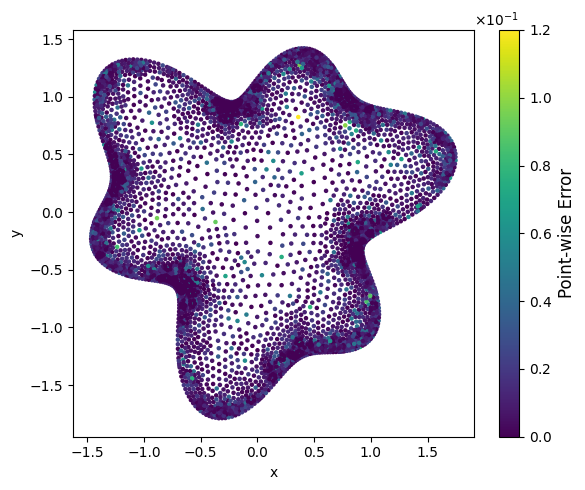

In [15]:
import matplotlib.ticker as ticker

key = 100
np.random.seed(key)
torch.manual_seed(key)
torch.cuda.manual_seed_all(key)

hidden_size = 50
Phi = PhiNet(input_size=1, hidden_size=hidden_size, output_size=1).to(device) #
Phi.initi()
Phi = Phi.double() 

# u_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
f_func = lambda x, y, t: np.sin(x) * np.cos(y) * np.exp(-t)
g_func = lambda x, y, t: 1 + np.sin(x) * np.cos(y) * np.exp(-t)
# u0_func = lambda x, y : 1 + np.sin(x) * np.cos(y)

tau = 1e-3
T = 2e-1 
Nt = int(T/tau) + 1
t =  np.linspace(0,T,Nt)

data = loadmat('./data/mydata_heat_pdetool_4029_T2e-1_tau1e-3.mat')
#'u0_0', 'uT_0', 'U0_new','UT_new', 'p','in','bc'
# (M,1), (M,NT),  (M,100), (100,M,NT)
p,u0_0,uT_0,U0_new,UT_new, index_in,index_bc = data['p'],data['u0_0'],data['uT_0'],data['U0_new'],data['UT_new'],data['in'],data['bc']  # sigma = 1, l = 0.25
index_in, index_bc = (index_in - 1).reshape(-1),(index_bc - 1).reshape(-1) # matlab to python index
# print("UT_new.shape,", UT_new.shape) # (n_batch,M,NT)

torchdtype = torch.float64
Y = p
M = Y.shape[0]
M2 = index_bc.shape[0]# 生成样本点已经给定
M1 = M - M2

U0_new = np.concatenate([U0_new[index_in,:],U0_new[index_bc,:]],axis=0)
testnum = 0
Yin,Yb = Y[index_in,:],Y[index_bc,:] # interior and boundary points
u0_func = U0_new[:,testnum]  # (M,)
order = 3
scheme = "BDF2"

reg = 1e-13
u_true = UT_new[testnum,:,:]
# print(u_true.shape) # (M,NT)
u_true = np.concatenate([u_true[index_in,:],u_true[index_bc,:]],axis=0)
# print(u_true.shape) # print(u_true.shape) # (M,NT)
# #===========================================================
# #==================== Source points X ====================
# #===========================================================
N_patch_grid = 5
N_local_per_patch = 100
N_boundary = 200
overlap = 0.2

# generate points
X_inner, X_boundary, C, R, _ = generator_points_2d_overlap(N_patch_grid, N_local_per_patch, N_boundary, overlap, False)
X = np.vstack([X_inner, X_boundary])
print(f"X.shape: {X.shape[0]}")


C, R, info = generate_patches_star_2d(X,target_n=100,delta=0.2,safety=1.35,margin=0.05,max_iter=10)
ptch = {
    "C": C,
    "R": R
}

# # ===========================================================
U,LBDF1,LBDF2,LI = rfm_fd_pum_poly_solve_heat_QR(ptch, X, Yin, Yb, t, tau, f_func, g_func, u0_func, Phi, reg, order,scheme=scheme)

# print("U.shape ",U.shape) #(M,NT)
error = np.abs(U- u_true)
error = np.max(np.max(error))

print(f'p = {order}; L infity error in u_rfmfd_pu: {error:.3e}')
error_u = relative_l2(U.ravel(), u_true.ravel())
print(f'p = {order}; Relative L2 error in u_rfmfd_pu: {error_u:.3e}')

error_u = relative_l2(U[:,-1:], u_true[:,-1:])
print(f'p = {order}; Relative L2 error at T time of u_rfmfd_pu: {error_u:.3e}')

e = np.abs(U[:,-1].ravel() - u_true[:,-1].ravel())
e =np.asarray(e)

for i in range(Nt):
    err_time = relative_l2(U[:,i], u_true[:,i])
    print(f'Time step {i}, Relative L2 error: {err_time:.3e}')

plt.figure(figsize=(6,5))
print(Y[:,0].shape, Y[:,1].shape, e.shape)
sc = plt.scatter(Y[:,0], Y[:,1], c = e, cmap='viridis', s=5)
cbar = plt.colorbar(sc)
cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
# plt.savefig(f'./result/p={order}_error_200_size{M}.eps', bbox_inches='tight')
plt.show()


UT_new.shape  (100, 4029, 201)
After reordering, U0_new.shape  (4029, 100)
p = 3, inference time: 28.9503 秒
error_L2.shape: (100, 1), error_inf.shape: (100, 4029, 201)
p = 3, test on 100 samples. The mean of max error: 1.804643e-01, and mean of relative L2 error: 1.520974e-02
p = 3, test on 100 samples. The variance of max error: 5.758790e-03, and variance of relative L2 error: 2.332768e-05
q = 70


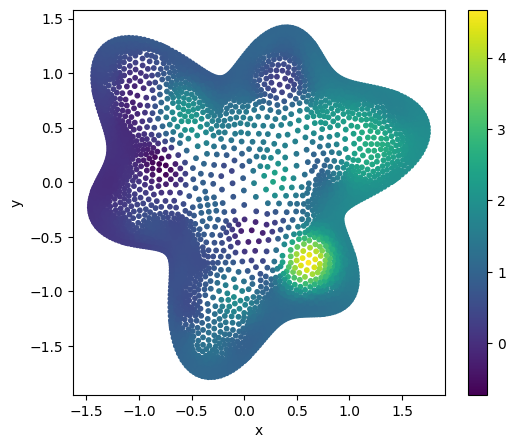

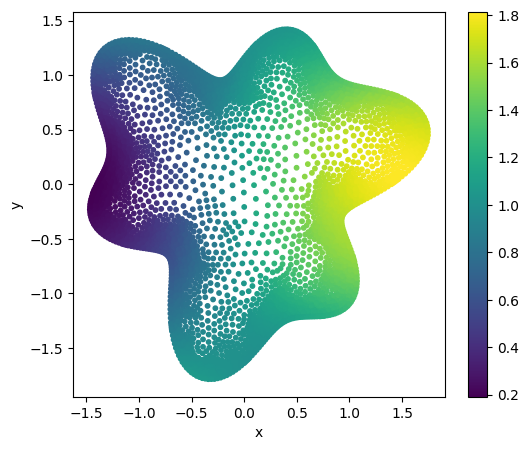

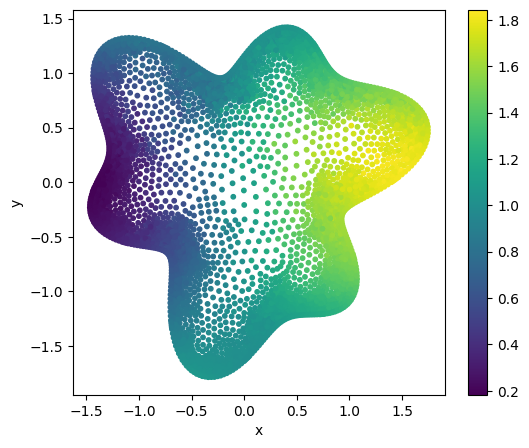

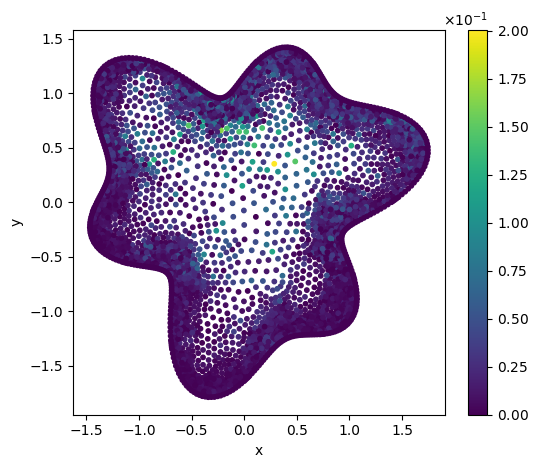

In [16]:
import time

E_inf, E_L2 = np.zeros((100,1)),np.zeros((100,1))
Y = np.concatenate([Yin, Yb], axis=0)

u_true = UT_new # (100,M,NT)
print( "UT_new.shape ", u_true.shape) 
u_true = np.concatenate([u_true[:,index_in,:],u_true[:,index_bc,:]], axis=1)

print("After reordering, U0_new.shape ", U0_new.shape) #(M,100)

start_time = time.time()
UY = test_solver(LBDF1, LBDF2, LI,
                f_func, g_func, U0_new,
                Yin, Yb, t, tau,
                scheme="BDF2") 
end_time = time.time()
print(f"p = {order}, inference time: {end_time - start_time:.4f} 秒")


error_inf = np.abs(UY - u_true) # (n_batch, M, NT)
E_inf =  np.max(np.max(error_inf, axis=2), axis=1) # (n_batch, 1)
error_L2 = (np.linalg.norm(UY - u_true, axis=(1,2)) / np.linalg.norm(u_true, axis=(1,2)))[:, None] # (n_batch, 1)
print(f"error_L2.shape: {error_L2.shape}, error_inf.shape: {error_inf.shape}") #(n_batch,1), (n_batch,M,NT)
E_L2 = error_L2

avg_inf = np.mean(E_inf)
avg_L2 = np.mean(E_L2)
var_inf = np.var(E_inf)
var_L2 = np.var(E_L2)

print(f"p = {order}, test on 100 samples. The mean of max error: {avg_inf:3e}, and mean of relative L2 error: {avg_L2:3e}")
print(f"p = {order}, test on 100 samples. The variance of max error: {var_inf:3e}, and variance of relative L2 error: {var_L2:3e}")

np.random.seed(30)
# q = np.random.randint(0, 100)
q = 70 
u_true_q = u_true[q,:,-1]
UY_q = UY[q,:,-1]
error_inf_q = error_inf[q,:,-1]
print("q =", q)
UY_0 = UY[q,:,0]


plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = UY_0, cmap='viridis', s=10)
plt.colorbar(sc)
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/heat_rfmfd_pou_p={order}_u_0_one_test_sample.eps', bbox_inches='tight')
plt.show()



plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = u_true_q, cmap='viridis', s=10)
plt.colorbar(sc)
# plt.title(f'u_fem')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/heat_rfmfd_pou_p={order}_u_fem_one_test_sample.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = UY_q, cmap='viridis', s=10)
plt.colorbar(sc)
# plt.colorbar(label='u_rfmfd_pou')
# plt.title(f'u_pred')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/heat_rfmfd_pou_p={order}_UY_one_test_sample.eps', bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(Y[:,0], Y[:,1], c = error_inf_q, cmap='viridis', s=10)
cbar = plt.colorbar(sc)
# cbar.set_label('Point-wise Error', fontsize=12)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.set_major_formatter(formatter)
plt.xlabel('x')
plt.ylabel('y')
plt.savefig(f'./result/heat_rfmfd_pou_p={order}_error_one_test_sample.eps', bbox_inches='tight')
plt.show()


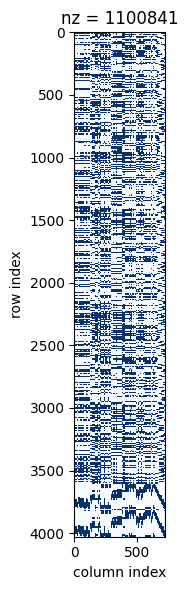

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp

def spy_like_matlab(A):
    import copy
    if sp.issparse(A):
        A = A.tocsr()
        M, N = A.shape
        img = np.zeros((M, N), dtype=np.uint8)
        img[A.nonzero()] = 1
    else:
        img = (A != 0).astype(np.uint8)

    my_cmap = copy.copy(plt.cm.Blues) # or plt.cm.plasma
    my_cmap.set_bad(color='white')
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=my_cmap, origin='upper', interpolation='nearest')
    plt.xlabel('column index')
    plt.ylabel('row index')
    plt.title(f'nz = {img.sum()}')
    plt.tight_layout()
    # plt.savefig('L.eps', bbox_inches='tight')
    plt.show()
spy_like_matlab(LBDF2)

In [ ]:
for name, param in Phi.named_parameters():
    print(name, param.data)

input_layer.weight tensor([[ 0.2842],
        [-0.2967],
        [-0.1604],
        [-0.2334],
        [-0.5244],
        [-0.0046],
        [-0.2725],
        [ 0.2287],
        [-0.2161],
        [-0.0757],
        [-0.0685],
        [ 0.0640],
        [ 0.3066],
        [ 0.3625],
        [-0.0834],
        [ 0.0658],
        [ 0.3209],
        [-0.0518],
        [-0.1160],
        [-0.0907],
        [ 0.1197],
        [ 0.0820],
        [-0.0369],
        [ 0.0720],
        [ 0.0468],
        [-0.0157],
        [-0.4444],
        [ 0.1845],
        [-0.0036],
        [ 0.0795],
        [-0.2547],
        [ 0.3697],
        [-0.0387],
        [-0.0531],
        [ 0.0157],
        [-0.1510],
        [ 0.3340],
        [-0.0718],
        [ 0.1586],
        [-0.2193],
        [ 0.1426],
        [-0.0696],
        [ 0.3045],
        [ 0.1889],
        [-0.2389],
        [ 0.2154],
        [-0.2263],
        [-0.0997],
        [ 0.0391],
        [-0.2642]], device='cuda:1', dtype=torch.f